# Import Library

In [ ]:
!pip install adjustText
from adjustText import adjust_text

In [ ]:
import pandas as pd
import json
import numpy as np
from scipy.stats import norm
from matplotlib.font_manager import FontProperties
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

!rm -rf ~/.cache/matplotlib

!apt-get install -y fonts-thai-tlwg

path = '/usr/share/fonts/truetype/tlwg/Loma.ttf'
thai_font = FontProperties(fname=path)

mpl.font_manager.fontManager.addfont(path)




plt.rcParams['font.family'] = 'Loma'
plt.rcParams['axes.unicode_minus'] = False

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-thai-tlwg is already the newest version (1:0.7.3-1).
0 upgraded, 0 newly installed, 0 to remove and 5 not upgraded.


# Import, Clean and Feature Data

In [ ]:
url_info_party_overview = "https://raw.githubusercontent.com/book150243/DADS5001/refs/heads/main/info_party_overview.json"
url_info_constituency = "https://raw.githubusercontent.com/book150243/DADS5001/refs/heads/main/info_constituency.json"
url_info_mp_candidate = "https://raw.githubusercontent.com/book150243/DADS5001/refs/heads/main/info_mp_candidate.json"
url_info_party_candidate = "https://raw.githubusercontent.com/book150243/DADS5001/refs/heads/main/info_party_candidate.json"
url_info_province = "https://raw.githubusercontent.com/book150243/DADS5001/refs/heads/main/info_province.json"
url_stats_party = "https://raw.githubusercontent.com/book150243/DADS5001/refs/heads/main/stats_party.json"
url_stats_cons =  "https://raw.githubusercontent.com/book150243/DADS5001/refs/heads/main/stats_cons.json"

df_party_overview = pd.read_json(url_info_party_overview)
df_constituency = pd.read_json(url_info_constituency)
df_mp_candidate = pd.read_json(url_info_mp_candidate)
df_party_candidate = pd.read_json(url_info_party_candidate)

In [ ]:
df_province_raw = pd.read_json(url_info_province)
df_province = pd.json_normalize(df_province_raw['province'])

df_stats_party_raw = pd.read_json(url_stats_party)
df_stats_party = pd.json_normalize(df_stats_party_raw['result_party'])

df_stats_cons_raw = pd.read_json(url_stats_cons)
df_stats_cons = pd.json_normalize(df_stats_cons_raw['result_province'])

In [ ]:
regions = {
    'Northern': ['เชียงราย', 'เชียงใหม่', 'น่าน', 'พะเยา', 'แพร่', 'แม่ฮ่องสอน', 'ลำปาง', 'ลำพูน', 'อุตรดิตถ์', 'สุโขทัย', 'พิษณุโลก', 'กำแพงเพชร'],
    'Northeastern': ['กาฬสินธุ์', 'ขอนแก่น', 'ชัยภูมิ', 'นครพนม', 'นครราชสีมา', 'บึงกาฬ', 'บุรีรัมย์', 'มหาสารคาม', 'มุกดาหาร', 'ยโสธร', 'ร้อยเอ็ด', 'เลย', 'สกลนคร', 'สุรินทร์', 'ศรีสะเกษ', 'หนองคาย', 'หนองบัวลำภู', 'อุดรธานี', 'อุบลราชธานี', 'อำนาจเจริญ'],
    'Central': ['นครสวรรค์', 'พิจิตร', 'เพชรบูรณ์', 'อุทัยธานี', 'ชัยนาท', 'สิงห์บุรี', 'อ่างทอง', 'ลพบุรี', 'สระบุรี', 'พระนครศรีอยุธยา', 'ปทุมธานี', 'นนทบุรี', 'นครปฐม', 'สมุทรสาคร', 'สมุทรสงคราม', 'สมุทรปราการ', 'นครนายก', 'สุพรรณบุรี'],
    'Eastern': ['จันทบุรี', 'ฉะเชิงเทรา', 'ชลบุรี', 'ตราด', 'ปราจีนบุรี', 'ระยอง', 'สระแก้ว'],
    'Western': ['ตาก', 'กาญจนบุรี', 'ราชบุรี', 'เพชรบุรี', 'ประจวบคีรีขันธ์'],
    'Southern': ['กระบี่', 'ชุมพร', 'ตรัง', 'นครศรีธรรมราช', 'นราธิวาส', 'ปัตตานี', 'พังงา', 'พัทลุง', 'ภูเก็ต', 'ระนอง', 'สตูล', 'สงขลา', 'สุราษฎร์ธานี', 'ยะลา'],
    'Bangkok': ['กรุงเทพมหานคร']
}


In [ ]:
regions_data_list = []
for region, provinces in regions.items():
    for province in provinces:
        regions_data_list.append({'province': province, 'region': region})
df_regions = pd.DataFrame(regions_data_list)

df_province = pd.merge(df_province, df_regions, on='province', how='left')
display(df_province.head())

,province_id,prov_id,province,abbre_thai,eng,total_vote_stations,total_registered_vote,region
0,10,BKK,กรุงเทพมหานคร,กทม,BKK,6757,4502458,Bangkok
1,11,SPK,สมุทรปราการ,สป,SPK,1771,1126420,Central
2,12,NBI,นนทบุรี,นบ,NBI,1559,1094383,Central
3,13,PTE,ปทุมธานี,ปท,PTE,1493,1012760,Central
4,14,AYA,พระนครศรีอยุธยา,อย,AYA,1160,677848,Central


In [ ]:
#ข้อมูลจำนวนพรรค
df_party_overview.sort_values('party_no').head()

,id,party_no,name,abbr,color,logo_url
0,254,1,ไทยทรัพย์ทวี,ททว.,#f02d30,https://static-ectreport69.ect.go.th/data/part...
1,185,2,เพื่อชาติไทย,พ.ชต.ท.,#724a34,https://static-ectreport69.ect.go.th/data/part...
2,244,3,ใหม่,ม,#da3731,https://static-ectreport69.ect.go.th/data/part...
3,228,4,มิติใหม่,มต.,#abc29d,https://static-ectreport69.ect.go.th/data/part...
4,250,5,รวมใจไทย,ร.จ.ท.,#eec49a,https://static-ectreport69.ect.go.th/data/part...


In [ ]:
#ข้อมูลของการรายเขต ของแต่ละจังหวัด (ผลโหวต, จำนวนจุดเลือกตั้ง)
df_constituency.sort_values('cons_id').head()

,cons_id,cons_no,prov_id,total_vote_stations,registered_vote,zone
172,ACR_1,1,ACR,323,145524.0,"[อำเภอเมืองอำนาจเจริญ, อำเภอหัวตะพาน]"
173,ACR_2,2,ACR,352,157184.0,"[อำเภอชานุมาน, อำเภอปทุมราชวงศา, อำเภอพนา, อำเ..."
64,ATG_1,1,ATG,249,111666.0,"[อำเภอเมืองอ่างทอง, อำเภอป่าโมก, อำเภอวิเศษชัย..."
65,ATG_2,2,ATG,256,112423.0,"[อำเภอไชโย, อำเภอโพธิ์ทอง, อำเภอแสวงหา, อำเภอว..."
59,AYA_1,1,AYA,239,140188.0,"[อำเภอพระนครศรีอยุธยา, อำเภอบางบาล]"


In [ ]:
#ข้อมูลรายชื่อและเลขของผู้สมัคร แบ่งตามเขต
df_mp_candidate[df_mp_candidate['mp_app_party_id']==34]

,mp_app_id,mp_app_no,mp_app_party_id,mp_app_name,image_url
0,KBI_1_1,1,34.0,นายสุวรรณ อินพรหม,https://static-ectreport69.ect.go.th/data/cand...
6,KBI_2_1,1,34.0,นายยุทธนา อ่าวลึกน้อย,https://static-ectreport69.ect.go.th/data/cand...
15,KBI_3_3,3,34.0,นายกุศล วะเจดีย์,https://static-ectreport69.ect.go.th/data/cand...
26,BKK_1_8,8,34.0,นายญาณกิตติ์ ห่วงทรัพย์,https://static-ectreport69.ect.go.th/data/cand...
41,BKK_2_5,5,34.0,นายเดวิด มกรพงศ์,https://static-ectreport69.ect.go.th/data/cand...
...,...,...,...,...,...
3457,UBN_7_5,5,34.0,นายเชิดศักดิ์ โภคกุลกานนท์,https://static-ectreport69.ect.go.th/data/cand...
3464,UBN_8_4,4,34.0,นางสาวจิตภินันท์ วงษ์ขันธ์,https://static-ectreport69.ect.go.th/data/cand...
3471,UBN_9_1,1,34.0,นายประภูศักดิ์ จินตะเวช,https://static-ectreport69.ect.go.th/data/cand...
3480,UBN_10_3,3,34.0,นายวัชรพล เชื้อคง,https://static-ectreport69.ect.go.th/data/cand...


In [ ]:
#key is last name use to join data บ้านใหญ่
df_mp_candidate[['first_name', 'last_name']] = df_mp_candidate['mp_app_name'].str.split(' ', n=1, expand=True)
df_mp_candidate.drop(columns= 'image_url', inplace= True)
df_mp_candidate.head()

,mp_app_id,mp_app_no,mp_app_party_id,mp_app_name,first_name,last_name
0,KBI_1_1,1,34.0,นายสุวรรณ อินพรหม,นายสุวรรณ,อินพรหม
1,KBI_1_2,2,63.0,นายกิตติ กิตติธรกุล,นายกิตติ,กิตติธรกุล
2,KBI_1_3,3,129.0,นายธนวัช ภูเก้าล้วน,นายธนวัช,ภูเก้าล้วน
3,KBI_1_4,4,1.0,นายวศิน สิริเกียรติกุล,นายวศิน,สิริเกียรติกุล
4,KBI_1_5,5,173.0,นายพิทักษ์ ภารา,นายพิทักษ์,ภารา


In [ ]:
#ระบบบัญชีรายชื่อ
df_ex_party_can = df_party_candidate.explode('party_list_candidates')
df_party_list_candidate = pd.json_normalize(df_ex_party_can['party_list_candidates'])
df_party_list_candidate['party_no']= df_ex_party_can['party_no'].values
df_party_list_candidate.sort_values('party_no')
df_party_list_candidate[['first_name', 'last_name']] = df_party_list_candidate['name'].str.split(' ', n=1, expand=True)
df_party_list_candidate.head()

,list_no,name,image_url,party_no,first_name,last_name
0,1,นายทวีทรัพย์ ตัดสมัย,https://cdn.ectscore69.ect.go.th/ect69/candida...,1,นายทวีทรัพย์,ตัดสมัย
1,2,นางเมลดา เกตุวิชิต,https://cdn.ectscore69.ect.go.th/ect69/candida...,1,นางเมลดา,เกตุวิชิต
2,3,นางพนิตพร ส่อนชัย,https://cdn.ectscore69.ect.go.th/ect69/candida...,1,นางพนิตพร,ส่อนชัย
3,1,นายพงษ์ฐวัฒน์ เตชะเดชเรืองกุล,https://cdn.ectscore69.ect.go.th/ect69/candida...,2,นายพงษ์ฐวัฒน์,เตชะเดชเรืองกุล
4,2,นายอชินาธิรัตน์ ฉัตรทวีวรชัย,https://cdn.ectscore69.ect.go.th/ect69/candida...,2,นายอชินาธิรัตน์,ฉัตรทวีวรชัย


In [ ]:
#candidate นายก (pm)
df_ex_party_can = df_party_candidate.explode('pm_candidates')
df_pm_candidate = pd.json_normalize(df_ex_party_can['pm_candidates'])
df_pm_candidate['party_no']= df_ex_party_can['party_no'].values
df_pm_candidate.sort_values('party_no')
df_pm_candidate[['first_name', 'last_name']] = df_pm_candidate['name'].str.split(' ', n=1, expand=True)
df_pm_candidate = df_pm_candidate.dropna(axis=0)
df_pm_candidate.drop(columns=['image_url'],inplace= True)
df_pm_candidate.head()

,name,party_no,first_name,last_name
2,สุรสิทธิ์ มัจฉาเดช,3,สุรสิทธิ์,มัจฉาเดช
3,ทรงตระกูล โสมคำ,3,ทรงตระกูล,โสมคำ
4,นวินดา สวัสดิ์เดชดี,3,นวินดา,สวัสดิ์เดชดี
7,พีระพันธุ์ สาลีรัฐวิภาค,6,พีระพันธุ์,สาลีรัฐวิภาค
8,อรรถวิชช์ สุวรรณภักดี,6,อรรถวิชช์,สุวรรณภักดี


In [ ]:
df_province #ข้อมูลภาพใหญ่รายจังหวัด

,province_id,prov_id,province,abbre_thai,eng,total_vote_stations,total_registered_vote,region
0,10,BKK,กรุงเทพมหานคร,กทม,BKK,6757,4502458,Bangkok
1,11,SPK,สมุทรปราการ,สป,SPK,1771,1126420,Central
2,12,NBI,นนทบุรี,นบ,NBI,1559,1094383,Central
3,13,PTE,ปทุมธานี,ปท,PTE,1493,1012760,Central
4,14,AYA,พระนครศรีอยุธยา,อย,AYA,1160,677848,Central
...,...,...,...,...,...,...,...,...
72,92,TRG,ตรัง,ตง,TRG,943,510403,Southern
73,93,PLG,พัทลุง,พท,PLG,806,422693,Southern
74,94,PTN,ปัตตานี,ปน,PTN,982,525674,Southern
75,95,YLA,ยะลา,ยล,YLA,708,395865,Southern


In [ ]:
#df_stats_party = df_stats_party.drop('candidates', axis = 1)  #ข้อมูลการได้รับผลโหวดของแต่ละ Party ต้องไปแตกด้านหลังออก
df_stats_party_clean = df_stats_party.drop(columns = 'candidates')
df_stats_party_clean.head()

,party_id,party_vote,party_vote_percent,party_list_count,mp_app_vote,mp_app_vote_percent,first_mp_app_count
0,254,285497,0.82436,None,2440,0.00705,0
1,185,629628,1.81802,None,459,0.00133,0
2,244,294502,0.85036,None,653,0.00189,0
3,228,230307,0.66500,None,1205,0.00348,0
4,250,404166,1.16701,None,2638,0.00762,0


In [ ]:
df_stats_cons_clean = df_stats_cons.drop(columns = ['constituencies','result_party'])
df_stats_cons_clean.to_csv('perc.csv')

In [ ]:
df_exploded = df_stats_party.explode('candidates')
df_candidates_vote_by_party = pd.json_normalize(df_exploded['candidates'])
df_candidates_vote_by_party['party_id'] = df_exploded['party_id'].values
df_candidates_vote_by_party.sort_values('mp_app_id').head()

,mp_app_id,mp_app_vote,mp_app_vote_percent,mp_app_rank,party_id
2658,ACR_1_1,828,1.03957,7,192
2997,ACR_1_2,14152,17.76818,3,129
557,ACR_1_3,19263,24.18516,2,34
1446,ACR_1_4,1672,2.09924,5,1
2000,ACR_1_5,40261,50.54866,1,63


In [ ]:
df_exploded_2 = df_stats_cons.explode('result_party')
df_result_par_stats_con = pd.json_normalize(df_exploded_2['result_party'])
df_result_par_stats_con['prov_id']= df_exploded_2['prov_id'].values
df_result_par_stats_con.sort_values('party_id')
df_result_par_stats_con.head()

,party_id,party_list_vote,party_cons_votes,first_mp_app_count,party_list_vote_percent,party_cons_votes_percent,prov_id
0,254.0,3092,0,0,0.10596,0.0,BKK
1,185.0,9760,0,0,0.33448,0.0,BKK
2,244.0,2534,0,0,0.08684,0.0,BKK
3,228.0,4126,0,0,0.14140,0.0,BKK
4,250.0,6431,0,0,0.22039,0.0,BKK


In [ ]:
df_exploded_3 = df_stats_cons.explode('constituencies')
df_constituencies = pd.json_normalize(df_exploded_3['constituencies'])
df_constituencies['prov_id']= df_exploded_3['prov_id'].values
df_constituencies.sort_values('cons_id')
df_constituencies_clean = df_constituencies.drop(columns=["candidates","result_party"])
df_constituencies_clean.head()

,cons_id,turn_out,percent_turn_out,valid_votes,invalid_votes,blank_votes,party_list_turn_out,party_list_percent_turn_out,party_list_valid_votes,party_list_invalid_votes,party_list_blank_votes,counted_vote_stations,percent_count,pause_report,prov_id
0,BKK_0,0,0.00000,0,0,0,0,0.00000,0,0,0,16,16.84211,False,BKK
1,BKK_1,78449,60.14967,73354,1083,4012,78155,59.92425,74515,1590,2050,227,94.97908,False,BKK
2,BKK_2,84672,62.03940,78713,1319,4640,84550,61.95002,80804,1432,2314,220,94.82759,False,BKK
3,BKK_3,77999,63.63214,72671,1353,3975,78327,63.89972,75007,1381,1939,206,94.93088,False,BKK
4,BKK_4,74760,57.75069,70338,1370,3052,74571,57.60469,71263,1586,1722,187,94.92386,False,BKK


In [ ]:
#ข้อมูลเดียวกับ stats_party
df_exploded_4 = df_constituencies.explode('candidates')
df_candidates_from_stats_con = pd.json_normalize(df_exploded_4['candidates'])
df_candidates_from_stats_con['cons_id']= df_exploded_4['cons_id'].values
df_candidates_from_stats_con.drop(index=0, inplace=True)
df_candidates_from_stats_con.sort_values('mp_app_id', inplace= True)
df_candidates_from_stats_con
#df_candidates_from_stats_con.to_csv('check_3.csv')

,mp_app_id,mp_app_vote,mp_app_vote_percent,mp_app_rank,party_id,cons_id
1671,ACR_1_1,828.0,1.03957,7.0,192.0,ACR_1
1667,ACR_1_2,14152.0,17.76818,3.0,129.0,ACR_1
1666,ACR_1_3,19263.0,24.18516,2.0,34.0,ACR_1
1669,ACR_1_4,1672.0,2.09924,5.0,1.0,ACR_1
1665,ACR_1_5,40261.0,50.54866,1.0,63.0,ACR_1
...,...,...,...,...,...,...
1600,YST_3_4,2263.0,2.57437,4.0,218.0,YST_3
1603,YST_3_5,395.0,0.44935,7.0,1.0,YST_3
1604,YST_3_6,238.0,0.27075,8.0,109.0,YST_3
1601,YST_3_7,623.0,0.70872,5.0,173.0,YST_3


In [ ]:
#key
url_df_bigdhouse = "https://github.com/book150243/DADS5001/raw/refs/heads/main/%E0%B8%95%E0%B8%A3%E0%B8%B0%E0%B8%81%E0%B8%B9%E0%B8%A5%E0%B8%9A%E0%B9%89%E0%B8%B2%E0%B8%99%E0%B9%83%E0%B8%AB%E0%B8%8D%E0%B9%88.xlsx"
df_bigdhouse = pd.read_excel(url_df_bigdhouse)
df_bigdhouse = df_bigdhouse.rename(columns={'ภาค':'region','จังหวัด':'province', 'สังกัดพรรค 2566':'party_2566', 'สังกัดพรรค 2569':'party_2569','บ้านใหญ่ย้ายพรรคหรือไม่':'Transfer_party', 'ตระกูลบ้านใหญ่':'last_name' })
df_bigdhouse['bighouse'] = "bighouse"
df_bigdhouse.head()

,region,province,last_name,party_2566,party_2569,Transfer_party,bighouse
0,กลาง,กรุงเทพ,คงอุดม,รวมไทยสร้างชาติ,รวมไทยสร้างชาติ,ไม่ย้าย,bighouse
1,กลาง,กรุงเทพ,ห่วงทรัพย์,เพื่อไทย,เพื่อไทย,ไม่ย้าย,bighouse
2,กลาง,กรุงเทพ,รัสมี,พลังประชารัฐ,เพื่อไทย,ย้าย,bighouse
3,กลาง,กรุงเทพ,มีนชัยนันท์,เพื่อไทย,เพื่อไทย,ไม่ย้าย,bighouse
4,กลาง,กรุงเทพ,มีนชัยนันท์,ประชาชน,ประชาชน,ไม่ย้าย,bighouse


In [ ]:
df_cand_with_party_name = pd.merge(df_mp_candidate, df_party_overview, left_on= 'mp_app_party_id', right_on= 'id', how = 'left')
df_cand_with_party_name['name']

,name
0,เพื่อไทย
1,ภูมิใจไทย
2,ประชาชน
3,ประชาธิปัตย์
4,เศรษฐกิจ
...,...
3486,ภูมิใจไทย
3487,เพื่อไทย
3488,กล้าธรรม
3489,ประชาชน


In [ ]:
df_mp_and_bighouse = pd.merge(df_cand_with_party_name, df_bigdhouse, left_on= ['last_name','name'] , right_on= ['last_name','party_2569'], how = 'left')
df_mp_and_bighouse

,mp_app_id,mp_app_no,mp_app_party_id,mp_app_name,first_name,last_name,id,party_no,name,abbr,color,logo_url,region,province,party_2566,party_2569,Transfer_party,bighouse
0,KBI_1_1,1,34.0,นายสุวรรณ อินพรหม,นายสุวรรณ,อินพรหม,34.0,9.0,เพื่อไทย,พท.,#da3731,https://static-ectreport69.ect.go.th/data/part...,NaN,NaN,NaN,NaN,NaN,NaN
1,KBI_1_2,2,63.0,นายกิตติ กิตติธรกุล,นายกิตติ,กิตติธรกุล,63.0,37.0,ภูมิใจไทย,ภท.,#0c149c,https://static-ectreport69.ect.go.th/data/part...,ใต้,กระบี่,ภูมิใจไทย,ภูมิใจไทย,ไม่ย้าย,bighouse
2,KBI_1_3,3,129.0,นายธนวัช ภูเก้าล้วน,นายธนวัช,ภูเก้าล้วน,129.0,46.0,ประชาชน,ปชน,#fd6512,https://static-ectreport69.ect.go.th/data/part...,ใต้,กระบี่,ประชาธิปัตย์,ประชาชน,ย้าย,bighouse
3,KBI_1_4,4,1.0,นายวศิน สิริเกียรติกุล,นายวศิน,สิริเกียรติกุล,1.0,27.0,ประชาธิปัตย์,ปชป.,#06aff3,https://static-ectreport69.ect.go.th/data/part...,NaN,NaN,NaN,NaN,NaN,NaN
4,KBI_1_5,5,173.0,นายพิทักษ์ ภารา,นายพิทักษ์,ภารา,173.0,11.0,เศรษฐกิจ,ศก,#f7c036,https://static-ectreport69.ect.go.th/data/part...,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3486,UBN_11_3,3,63.0,นางสาวตวงทิพย์ จินตะเวช,นางสาวตวงทิพย์,จินตะเวช,63.0,37.0,ภูมิใจไทย,ภท.,#0c149c,https://static-ectreport69.ect.go.th/data/part...,NaN,NaN,NaN,NaN,NaN,NaN
3487,UBN_11_4,4,34.0,นางอุบล สิมมา,นางอุบล,สิมมา,34.0,9.0,เพื่อไทย,พท.,#da3731,https://static-ectreport69.ect.go.th/data/part...,NaN,NaN,NaN,NaN,NaN,NaN
3488,UBN_11_5,5,218.0,นายสมมาตร มะลิลา,นายสมมาตร,มะลิลา,218.0,42.0,กล้าธรรม,กธ,#55CF6A,https://static-ectreport69.ect.go.th/data/part...,NaN,NaN,NaN,NaN,NaN,NaN
3489,UBN_11_6,6,129.0,นายธีรศักดิ์ วีระจินตวงศ์,นายธีรศักดิ์,วีระจินตวงศ์,129.0,46.0,ประชาชน,ปชน,#fd6512,https://static-ectreport69.ect.go.th/data/part...,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#เริ่มจาก สส แบ่งเขต
#ต้อง join จาก party list เพิ่มด้วยไม่งั้นเบิ้ล
df_cal_score_per_candidate = pd.merge(df_candidates_from_stats_con, df_constituencies_clean, left_on= 'cons_id' , right_on= 'cons_id', how = 'left')

df_cal_score_per_candidate_bighouse = pd.merge(df_cal_score_per_candidate, df_mp_and_bighouse, left_on= ['mp_app_id','party_id'] , right_on= ['mp_app_id','mp_app_party_id'], how = 'left')
df_cal_score_per_candidate_bighouse['bighouse'] = df_cal_score_per_candidate_bighouse['bighouse'].fillna(value = "not_bighouse")
df_cal_score_per_candidate_bighouse['is_winner'] = (df_cal_score_per_candidate_bighouse['mp_app_rank'] ==1).astype(int)
df_cal_score_per_candidate_bighouse.sort_values('mp_app_id')
df_cal_score_per_candidate_bighouse = pd.merge(df_cal_score_per_candidate_bighouse,df_province, left_on = 'prov_id', right_on = 'prov_id', how= 'left')
#df_cal_score_per_candidate_bighouse[df_cal_score_per_candidate_bighouse['mp_app_rank']==1]
df_cal_score_per_candidate_bighouse

,mp_app_id,mp_app_vote,mp_app_vote_percent,mp_app_rank,party_id,cons_id,turn_out,percent_turn_out,valid_votes,invalid_votes,...,Transfer_party,bighouse,is_winner,province_id,province_y,abbre_thai,eng,total_vote_stations,total_registered_vote,region_y
0,ACR_1_1,828.0,1.03957,7.0,192.0,ACR_1,85388,58.67623,79648,2654,...,NaN,not_bighouse,0,37,อำนาจเจริญ,อจ,ACR,675,302708,Northeastern
1,ACR_1_2,14152.0,17.76818,3.0,129.0,ACR_1,85388,58.67623,79648,2654,...,NaN,not_bighouse,0,37,อำนาจเจริญ,อจ,ACR,675,302708,Northeastern
2,ACR_1_3,19263.0,24.18516,2.0,34.0,ACR_1,85388,58.67623,79648,2654,...,ไม่ย้าย,bighouse,0,37,อำนาจเจริญ,อจ,ACR,675,302708,Northeastern
3,ACR_1_4,1672.0,2.09924,5.0,1.0,ACR_1,85388,58.67623,79648,2654,...,NaN,not_bighouse,0,37,อำนาจเจริญ,อจ,ACR,675,302708,Northeastern
4,ACR_1_5,40261.0,50.54866,1.0,63.0,ACR_1,85388,58.67623,79648,2654,...,ไม่ย้าย,bighouse,1,37,อำนาจเจริญ,อจ,ACR,675,302708,Northeastern
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3486,YST_3_4,2263.0,2.57437,4.0,218.0,YST_3,93197,63.56624,87905,3394,...,NaN,not_bighouse,0,35,ยโสธร,ยส,YST,926,432508,Northeastern
3487,YST_3_5,395.0,0.44935,7.0,1.0,YST_3,93197,63.56624,87905,3394,...,NaN,not_bighouse,0,35,ยโสธร,ยส,YST,926,432508,Northeastern
3488,YST_3_6,238.0,0.27075,8.0,109.0,YST_3,93197,63.56624,87905,3394,...,NaN,not_bighouse,0,35,ยโสธร,ยส,YST,926,432508,Northeastern
3489,YST_3_7,623.0,0.70872,5.0,173.0,YST_3,93197,63.56624,87905,3394,...,NaN,not_bighouse,0,35,ยโสธร,ยส,YST,926,432508,Northeastern


In [ ]:
df_cal_margin = df_cal_score_per_candidate_bighouse

df_cal_margin['mp_app_vote_portion'] = df_cal_margin['mp_app_vote_percent']/100
df_cal_margin['vote_portion^2'] = df_cal_margin['mp_app_vote_portion']**2

df_cal_margin = pd.merge(df_cal_margin, df_constituency, left_on= 'cons_id', right_on = 'cons_id', how = 'left')
df_cal_margin = pd.merge(df_cal_margin, df_province, left_on= 'prov_id_y', right_on = 'prov_id', how = 'left')

mapping_bh = {'bighouse': 1, 'not_bighouse': 0}

df_cal_margin['bighouse_no'] = df_cal_margin['bighouse'].map(mapping_bh)
df_cal_margin

#ต้องใช้อันนี้ df_candidates_from_stats_con
#df_cal_margin = df_cal_score_per_candidate_bighouse.merge(df_cal_score_per_candidate_bighouse, df_cal_margin, left_on= ['cons_id','mp_app_rank'] , right_on= ['cons_id','mp_app_rank'], how = 'left')

,mp_app_id,mp_app_vote,mp_app_vote_percent,mp_app_rank,party_id,cons_id,turn_out,percent_turn_out,valid_votes,invalid_votes,...,zone,province_id_y,prov_id,province,abbre_thai_y,eng_y,total_vote_stations,total_registered_vote_y,region,bighouse_no
0,ACR_1_1,828.0,1.03957,7.0,192.0,ACR_1,85388,58.67623,79648,2654,...,"[อำเภอเมืองอำนาจเจริญ, อำเภอหัวตะพาน]",37,ACR,อำนาจเจริญ,อจ,ACR,675,302708,Northeastern,0
1,ACR_1_2,14152.0,17.76818,3.0,129.0,ACR_1,85388,58.67623,79648,2654,...,"[อำเภอเมืองอำนาจเจริญ, อำเภอหัวตะพาน]",37,ACR,อำนาจเจริญ,อจ,ACR,675,302708,Northeastern,0
2,ACR_1_3,19263.0,24.18516,2.0,34.0,ACR_1,85388,58.67623,79648,2654,...,"[อำเภอเมืองอำนาจเจริญ, อำเภอหัวตะพาน]",37,ACR,อำนาจเจริญ,อจ,ACR,675,302708,Northeastern,1
3,ACR_1_4,1672.0,2.09924,5.0,1.0,ACR_1,85388,58.67623,79648,2654,...,"[อำเภอเมืองอำนาจเจริญ, อำเภอหัวตะพาน]",37,ACR,อำนาจเจริญ,อจ,ACR,675,302708,Northeastern,0
4,ACR_1_5,40261.0,50.54866,1.0,63.0,ACR_1,85388,58.67623,79648,2654,...,"[อำเภอเมืองอำนาจเจริญ, อำเภอหัวตะพาน]",37,ACR,อำนาจเจริญ,อจ,ACR,675,302708,Northeastern,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3486,YST_3_4,2263.0,2.57437,4.0,218.0,YST_3,93197,63.56624,87905,3394,...,"[อำเภอกุดชุม, อำเภอเลิงนกทา, อำเภอไทยเจริญ (ยก...",35,YST,ยโสธร,ยส,YST,926,432508,Northeastern,0
3487,YST_3_5,395.0,0.44935,7.0,1.0,YST_3,93197,63.56624,87905,3394,...,"[อำเภอกุดชุม, อำเภอเลิงนกทา, อำเภอไทยเจริญ (ยก...",35,YST,ยโสธร,ยส,YST,926,432508,Northeastern,0
3488,YST_3_6,238.0,0.27075,8.0,109.0,YST_3,93197,63.56624,87905,3394,...,"[อำเภอกุดชุม, อำเภอเลิงนกทา, อำเภอไทยเจริญ (ยก...",35,YST,ยโสธร,ยส,YST,926,432508,Northeastern,0
3489,YST_3_7,623.0,0.70872,5.0,173.0,YST_3,93197,63.56624,87905,3394,...,"[อำเภอกุดชุม, อำเภอเลิงนกทา, อำเภอไทยเจริญ (ยก...",35,YST,ยโสธร,ยส,YST,926,432508,Northeastern,0


In [ ]:
#ทำ Table ภาพรวม
df_overview_vote = pd.merge(df_stats_cons_clean,df_province, left_on = 'prov_id', right_on = 'prov_id', how= 'left')
df_overview_vote['Thailand'] = 'Thailand'
df_overview_vote

,prov_id,turn_out,percent_turn_out,valid_votes,invalid_votes,blank_votes,party_list_turn_out,party_list_percent_turn_out,party_list_valid_votes,party_list_invalid_votes,...,percent_count,pause_report,province_id,province,abbre_thai,eng,total_vote_stations_y,total_registered_vote_y,region,Thailand
0,BKK,2921346,64.88336,2717431,48559,155356,2917995,64.80893,2784699,53965,...,93.07385,False,10,กรุงเทพมหานคร,กทม,BKK,6757,4502458,Bangkok,Thailand
1,SPK,750303,66.60952,688634,21038,40631,752183,66.77642,705047,21431,...,94.74873,False,11,สมุทรปราการ,สป,SPK,1771,1126420,Central,Thailand
2,NBI,730832,66.78028,668274,17102,45456,730093,66.71275,688945,16247,...,92.49519,False,12,นนทบุรี,นบ,NBI,1559,1094383,Central,Thailand
3,PTE,705103,69.62192,651385,18204,35514,705411,69.65234,664086,19402,...,94.77562,False,13,ปทุมธานี,ปท,PTE,1493,1012760,Central,Thailand
4,AYA,498076,73.47901,461803,17095,19178,495773,73.13926,454884,23333,...,94.91379,False,14,พระนครศรีอยุธยา,อย,AYA,1160,677848,Central,Thailand
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,TRG,363165,71.15260,338154,8288,16723,369314,72.35733,349068,10627,...,94.80382,False,92,ตรัง,ตง,TRG,943,510403,Southern,Thailand
73,PLG,329838,78.03252,313383,7185,9270,314194,74.33149,299306,9922,...,94.66501,False,93,พัทลุง,พท,PLG,806,422693,Southern,Thailand
74,PTN,354370,67.41250,333392,12105,8873,358666,68.22974,333265,18756,...,94.80652,False,94,ปัตตานี,ปน,PTN,982,525674,Southern,Thailand
75,YLA,271680,68.62946,247511,11779,12390,268043,67.71071,246621,13843,...,94.77401,False,95,ยะลา,ยล,YLA,708,395865,Southern,Thailand


# กราฟเทียบสัดส่วนการได้เก้าอี้ของ สส กลุ่มที่เป็น bighouse และไม่เป็น bighouse

,bighouse,is_winner,mp_app_name,win_rate
0,bighouse,127,222,57.21%
1,not_bighouse,273,3269,8.35%


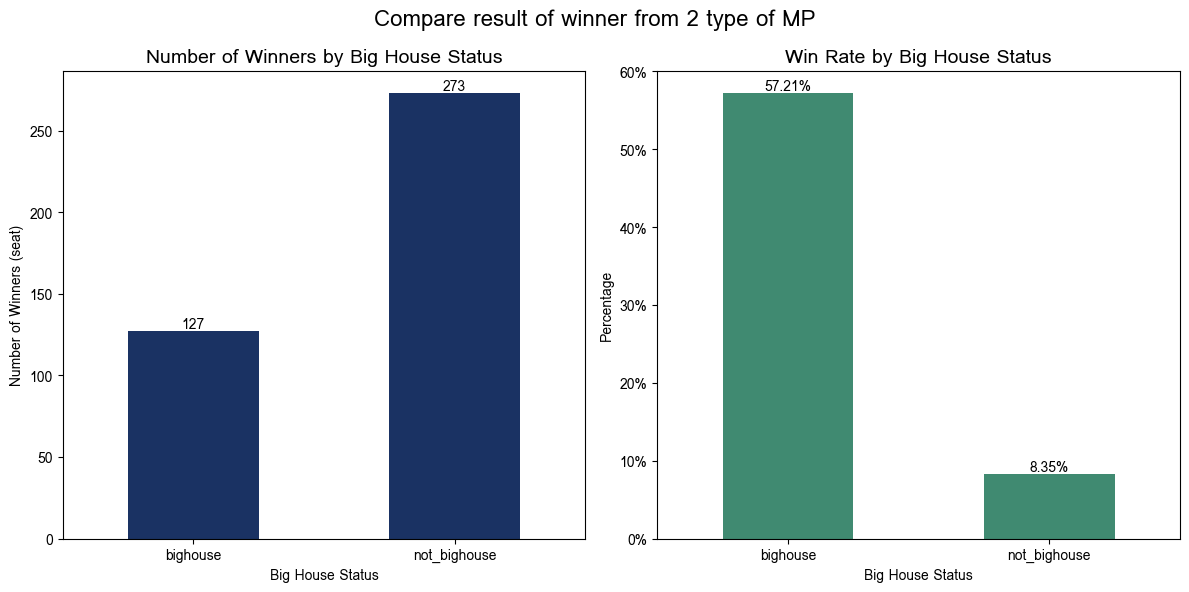

In [ ]:
import matplotlib.ticker as mticker

check_winner_graph= pd.pivot_table(
    df_cal_score_per_candidate_bighouse,
    values = 'is_winner',
    index = 'bighouse',
    aggfunc = {
        'is_winner' : 'sum'}
)

count_bighouse = pd.pivot_table(
    df_cal_score_per_candidate_bighouse,
    values = ['mp_app_name','is_winner'],
    index = ['bighouse'],
    aggfunc = {
        'mp_app_name': 'count',
        'is_winner' : 'sum',
    }
)

count_bighouse = count_bighouse.reset_index(None)
color_negative , color_positive = 'red', 'green'
count_bighouse['win_rate'] = (count_bighouse['is_winner'] / count_bighouse['mp_app_name']) * 100
display_count_bighouse_win = count_bighouse.style.bar(
                                subset='win_rate',
                                align = 'left',
                                vmin = 0, vmax = 100,
                                height = 60,
                                width = 100,
                                color=[color_negative, color_positive]
                            ).format({'win_rate': '{:.2f}%'}).set_table_styles([
                                {'selector': 'th', 'props': [('border', '1px solid black')]},
                                {'selector': 'td', 'props': [('border', '1px solid black')]}
                                ])

display(display_count_bighouse_win)

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Compare result of winner from 2 type of MP', fontsize=16)

# Plot the first graph (number of winners)
check_winner_graph.plot(kind='bar', ax=axes[0], color='#1A3263', legend = False)
axes[0].set_title('Number of Winners by Big House Status', fontsize=14)
axes[0].set_ylabel('Number of Winners (seat)')
axes[0].set_xlabel('Big House Status')
axes[0].tick_params(axis='x', rotation=0)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d')

# Plot the second graph (win rate)
count_bighouse.set_index('bighouse')['win_rate'].plot(kind='bar', ax=axes[1], color='#408A71', label='Win Rate %', legend= False)
axes[1].set_title('Win Rate by Big House Status', fontsize=14)
axes[1].set_ylabel('Percentage')
axes[1].set_xlabel('Big House Status')
axes[1].tick_params(axis='x', rotation=0)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.2f%%')

plt.tight_layout()
plt.show()

figure x.x show the winner MP on each constuetency in Thailand.

จากรูปเราจะเห็นว่า สส ผู้ที่มีส่วนเกี่ยวข้องกับ bighouse จะมีจำนวนคนชนะน้อยกว่า สส ผู้ที่ไม่เกี่ยวข้องกับ bighouse แต่ถ้าดูในสัดส่วนจะเห็นได้ชัดว่าสัดส่วนของจำนวนผู้ที่ชนะแล้วเกี่ยวข้องกับ bighouse นั้นจะอยู่ที่ 54.21% ซึ่งสูงกว่าผู้ที่ไม่เกี่ยวกับ bighouse มาก ทำให้เห็นได้ว่าการเป็น สส ที่เกี่ยวข้องกับบ้านใหญ่จะมีโอกาสชนะถ้าเทียบกับการเป็น สส ที่ไม่เกี่ยวข้องกับบ้านใหญ่

# กราฟจำนวนผู้ชนะในแต่ละภูมิภาคแบ่งตามผู้สมัคร สส ที่เกี่ยวข้องกับบ้านใหญ่และไม่เกี่ยวข้อง

,Region,Total Bighouse Winners,Total Bighouse Losers,Total Bighouse Candidates
0,Bangkok,1,12,13
1,Central,31,13,44
2,Eastern,9,6,15
3,Northeastern,44,34,78
4,Northern,16,15,31
5,Southern,19,13,32
6,Western,7,2,9


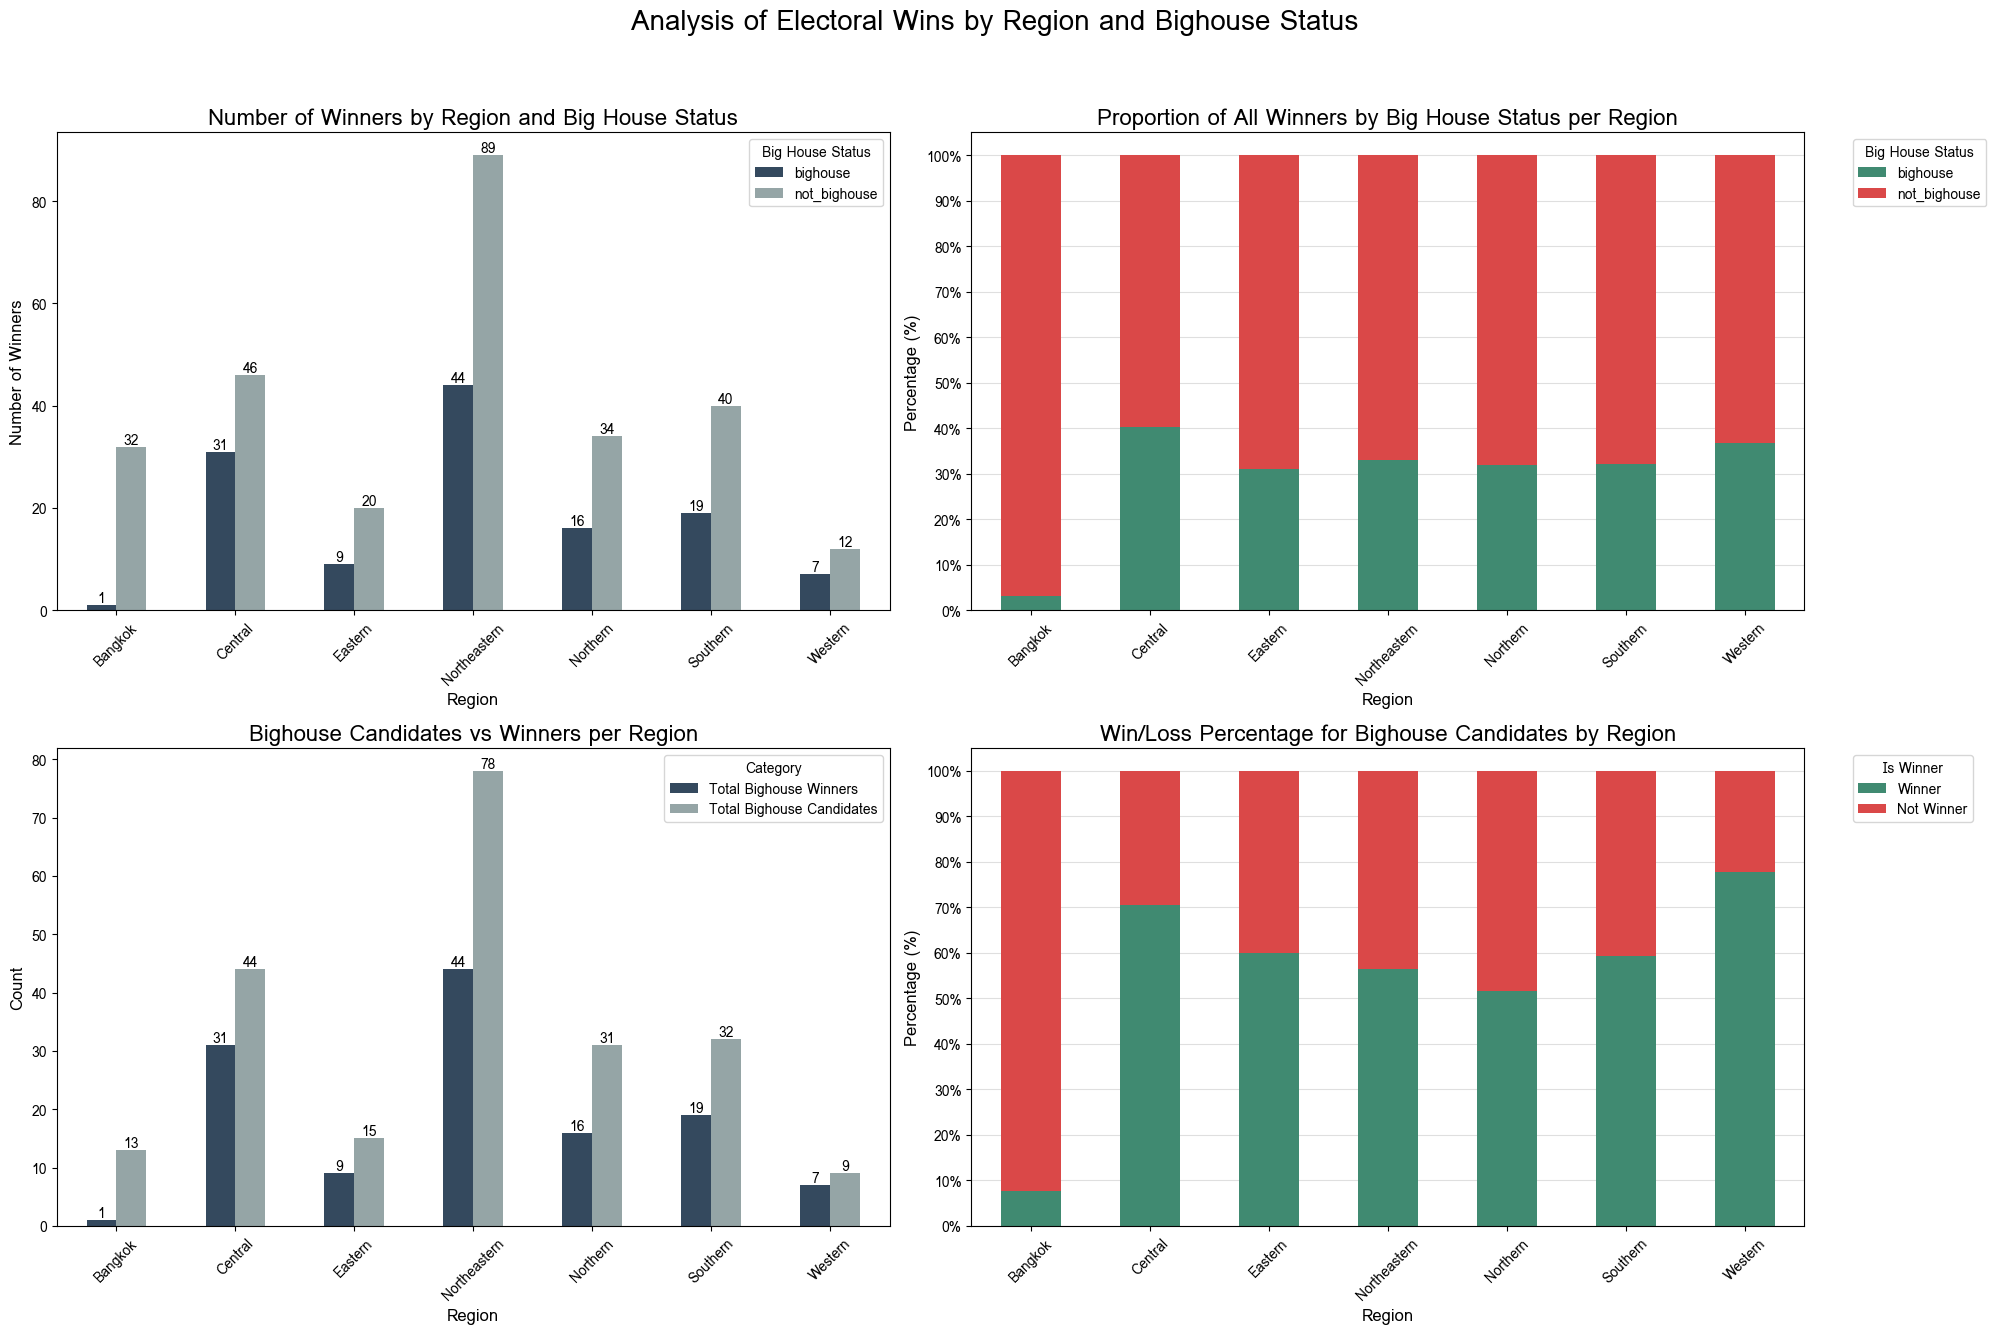

In [ ]:
import matplotlib.ticker as mticker
import numpy as np

# Group by region and bighouse status and sum the 'is_winner' column
winner_by_region_bighouse = df_cal_score_per_candidate_bighouse.groupby(['region_y', 'bighouse'])['is_winner'].sum().unstack(fill_value=0)

# Filter for bighouse candidates only and group by region and winner status
bighouse_candidates_by_region = df_cal_score_per_candidate_bighouse[
    df_cal_score_per_candidate_bighouse['bighouse'] == 'bighouse'
].groupby(['region_y', 'is_winner']).size().unstack(fill_value=0)

# Calculate percentages for bighouse candidates (among bighouse candidates)
bighouse_percentages_by_region = bighouse_candidates_by_region.apply(lambda x: x / x.sum() * 100, axis=1)

# Reorder columns for plotting: Winner (1) first, then Not Winner (0)
bighouse_percentages_by_region_reordered = bighouse_percentages_by_region[[1, 0]]

# Calculate total winners and non-winners for bighouse candidates per region
total_bighouse_winners_per_region = bighouse_candidates_by_region[1]
total_bighouse_losers_per_region = bighouse_candidates_by_region[0]
total_bighouse_candidates_per_region = bighouse_candidates_by_region.sum(axis=1)

# Create a DataFrame for the summary table indexed by region_y
bighouse_summary_table = pd.DataFrame({
    'Total Bighouse Winners': total_bighouse_winners_per_region,
    'Total Bighouse Losers': total_bighouse_losers_per_region,
    'Total Bighouse Candidates': total_bighouse_candidates_per_region
})

bighouse_summary_table = bighouse_summary_table.reset_index().rename(columns={'region_y': 'Region'})

# Calculate the proportion of bighouse vs. not_bighouse among *all* winners for each region
total_winners_per_region = winner_by_region_bighouse.sum(axis=1)
proportion_of_all_winners_by_bighouse_status = (
    winner_by_region_bighouse.div(total_winners_per_region.replace(0, np.nan), axis=0) * 100
).fillna(0)

# Overall winner count by bighouse status (from previous code, re-used here)
check_winner_graph = pd.pivot_table(
    df_cal_score_per_candidate_bighouse,
    values = 'is_winner',
    index = 'bighouse',
    aggfunc = {
        'is_winner' : 'sum'}
)


display(bighouse_summary_table)

# Plotting the four graphs in a 2x2 grid
fig, axes = plt.subplots(2,2, figsize=(20, 14))
fig.suptitle('Analysis of Electoral Wins by Region and Bighouse Status', fontsize=20)

# Plot 1: Number of Winners by Region and Big House Status (Top-Left)
winner_by_region_bighouse.plot(kind='bar', stacked=False, ax=axes[0,0], color=['#34495e', '#95a5a6'])
axes[0,0].set_title('Number of Winners by Region and Big House Status', fontsize=16)
axes[0,0].set_xlabel('Region', fontsize=12)
axes[0,0].set_ylabel('Number of Winners', fontsize=12)
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].legend(title='Big House Status')
for container in axes[0,0].containers:
    axes[0,0].bar_label(container, fmt='%d')

# Plot 2: Proportion of All Winners by Big House Status per Region (Top-Right)
proportion_of_all_winners_by_bighouse_status.plot(kind='bar', stacked=True, ax=axes[0,1], color=['#408A71', '#DA4848'])
axes[0,1].set_title('Proportion of All Winners by Big House Status per Region', fontsize=16)
axes[0,1].set_xlabel('Region', fontsize=12)
axes[0,1].set_ylabel('Percentage (%)', fontsize=12)
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].legend(title='Big House Status', bbox_to_anchor=(1.05, 1))
axes[0,1].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[0,1].set_yticks(np.arange(0, 101, 10)) # Set y-axis ticks to 10% intervals
axes[0,1].yaxis.grid(True, linestyle='-', alpha=0.4) # Add grid lines
axes[0,1].set_axisbelow(True)

# Plot 3: Number of Bighouse Candidates vs Winners per Region (Bottom-Left)
bighouse_summary_table_for_plot = bighouse_summary_table[['Region', 'Total Bighouse Winners' , 'Total Bighouse Candidates']].set_index('Region')
bighouse_summary_table_for_plot.plot(kind='bar', stacked=False, ax=axes[1, 0], color=['#34495e', '#95a5a6'])
axes[1, 0].set_title('Bighouse Candidates vs Winners per Region', fontsize=16)
axes[1, 0].set_xlabel('Region', fontsize=12)
axes[1, 0].set_ylabel('Count', fontsize=12)
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend(title='Category')
for container in axes[1, 0].containers:
    axes[1, 0].bar_label(container, fmt='%d')

# Plot 4: Percentage of Bighouse Winners vs Non-Winners by Region (Bottom-Right)
bighouse_percentages_by_region_reordered.plot(kind='bar', stacked=True, ax=axes[1, 1], color=['#408A71', '#DA4848'])
axes[1, 1].set_title('Win/Loss Percentage for Bighouse Candidates by Region', fontsize=16)
axes[1, 1].set_xlabel('Region', fontsize=12)
axes[1, 1].set_ylabel('Percentage (%)', fontsize=12)
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].legend(title='Is Winner', labels=['Winner', 'Not Winner'], bbox_to_anchor=(1.05, 1))
axes[1, 1].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[1, 1].set_yticks(np.arange(0, 101, 10)) # Set y-axis ticks to 10% intervals
axes[1, 1].yaxis.grid(True, linestyle='-', alpha=0.4) # Add grid lines
axes[1, 1].set_axisbelow(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

# กราฟเทียบจำนวนของ สส bighouse กับ สส ที่ไม่เป็น bighouse ของพรรค top5

,Member of the House of Representatives from bighouse,Member of the House of Representatives not from bighouse
party,,
ภูมิใจไทย,74,100
ประชาชน,3,84
เพื่อไทย,24,34
กล้าธรรม,19,37
ประชาธิปัตย์,4,6


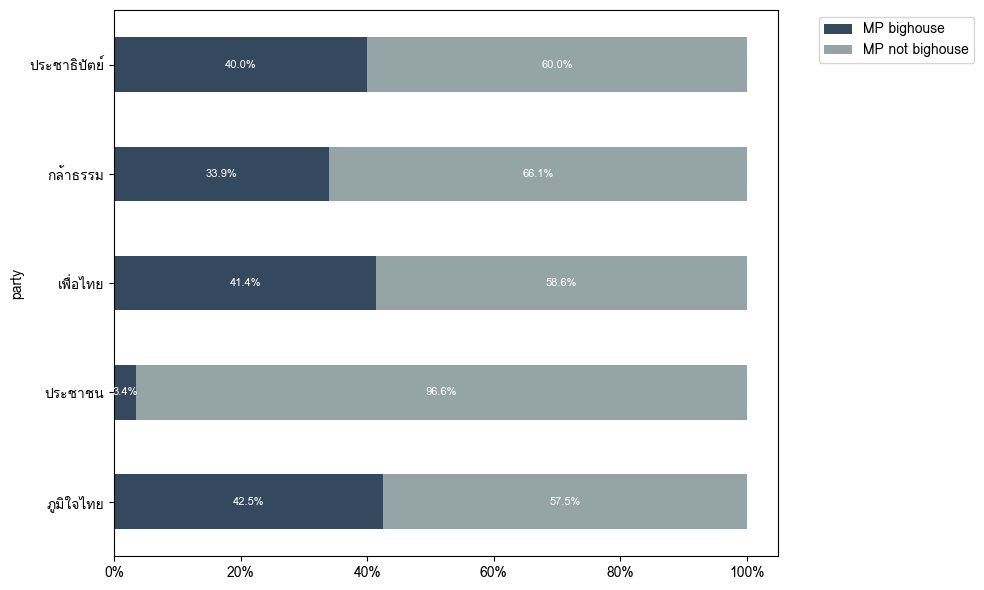

In [ ]:
import matplotlib.ticker as mticker

df_check_winner = df_cal_margin[df_cal_score_per_candidate_bighouse["mp_app_rank"]==1]

df_check_winner_pivot = pd.pivot_table(
    df_check_winner,
    values = ['bighouse','bighouse_no'],
    index = 'name',
    aggfunc = {
        'bighouse_no':'sum',
        'bighouse' : 'count'
    }
)
df_check_winner_pivot.reset_index(inplace= True)
df_check_winner_pivot.sort_values('bighouse', ascending= False, inplace= True)
df_check_winner_pivot = df_check_winner_pivot.rename(columns={'name':'party','bighouse':'Member of the House of Representatives','bighouse_no':'Member of the House of Representatives from bighouse'})
df_check_winner_pivot['Member of the House of Representatives not from bighouse'] = df_check_winner_pivot['Member of the House of Representatives'] - df_check_winner_pivot['Member of the House of Representatives from bighouse']
top_5_party_seat = df_check_winner_pivot.iloc[:,[0,2,3]].head()
top_5_party_seat = top_5_party_seat.set_index('party')

display(top_5_party_seat)

df_check_winner_pivot_perc = df_check_winner_pivot

target_cols = df_check_winner_pivot_perc.iloc[:, 2:4]

row_sums = target_cols.sum(axis=1)

df_check_winner_pivot_perc.iloc[:, 2:4] = target_cols.div(row_sums, axis=0)
df_check_winner_pivot_perc.iloc[:, 2:4] = df_check_winner_pivot_perc.iloc[:, 2:4] * 100
dis_df_check_winner_pivot_perc = df_check_winner_pivot_perc.iloc[:,[0,2,3]].set_index('party').head()
#display_df_check_winner_pivot_perc = df_check_winner_pivot_perc.iloc[:,[0,2,3]].style.format(
#    {'Member of the House of Representatives from bighouse':'{:.2f}%',
#     'Member of the House of Representatives not from bighouse':'{:.2f}%'})


ax = dis_df_check_winner_pivot_perc.plot(kind='barh', stacked=True, figsize=(10, 6), color=['#34495e', '#95a5a6'])
ax.legend(labels=['MP bighouse', 'MP not bighouse'], bbox_to_anchor=(1.05, 1), loc='upper left')
ax.xaxis.set_major_formatter(mticker.PercentFormatter())

for container in ax.containers:
    labels = [f'{w:.1f}%' if (w := v.get_width()) > 0 else '' for v in container]
    ax.bar_label(container, labels=labels, label_type='center', color='white', fontsize=8)

plt.tight_layout()
plt.show()

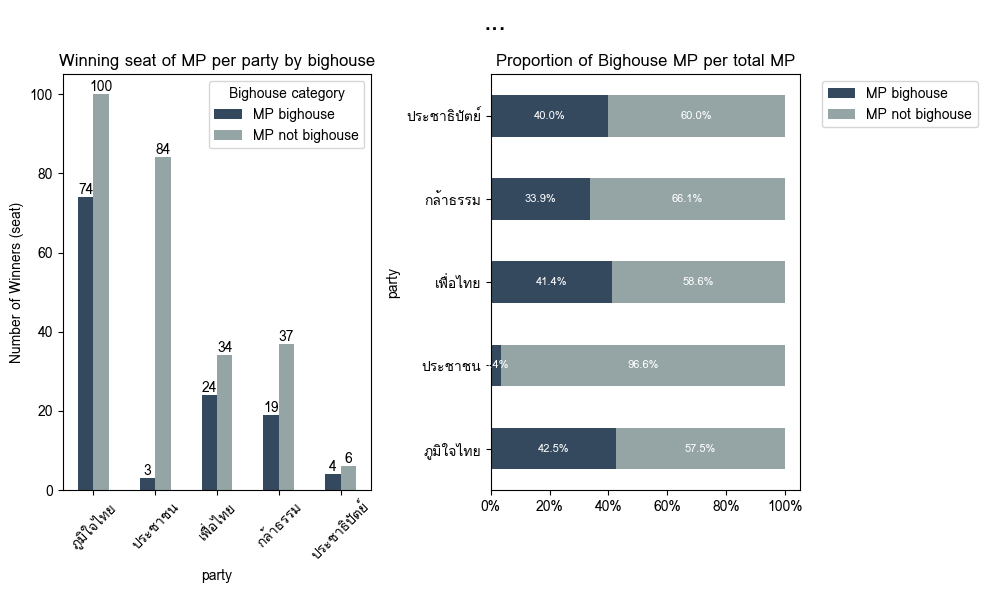

In [ ]:
fig, axes = plt.subplots(1,2, figsize = (12, 10))
fig.suptitle('...', fontsize =20)

top_5_party_seat.plot(kind = "bar",figsize = (10,6),ax= axes[0], color = ['#34495e', '#95a5a6'])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation= 45)
axes[0].legend(title = 'Bighouse category', labels = ['MP bighouse','MP not bighouse'])
axes[0].set_ylabel('Number of Winners (seat)')
axes[0].set_title('Winning seat of MP per party by bighouse')

for container in axes[0].containers:
    axes[0].bar_label(container, fmt = '%d')

dis_df_check_winner_pivot_perc.plot(kind='barh', stacked=True, figsize=(10, 6),ax= axes[1], color=['#34495e', '#95a5a6'])
axes[1].legend(labels=['MP bighouse', 'MP not bighouse'], bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].set_title('Proportion of Bighouse MP per total MP')

for container in axes[1].containers:
    labels = [f'{w:.1f}%' if (w := v.get_width()) > 0 else '' for v in container]
    axes[1].bar_label(container, labels=labels, label_type='center', color='white', fontsize=8)

plt.tight_layout()
plt.show()

# กราฟ bighouse ราย region ดูตามพรรค

In [ ]:
df_winners = df_cal_score_per_candidate_bighouse[df_cal_score_per_candidate_bighouse['is_winner'] == 1]

df_winning_candidates_aggregated = df_winners.groupby(['region_y', 'name', 'bighouse'])['is_winner'].sum().reset_index()
df_winning_candidates_aggregated = df_winning_candidates_aggregated.rename(columns={'is_winner': 'winning_seats'})

display(df_winning_candidates_aggregated)

,region_y,name,bighouse,winning_seats
0,Bangkok,ประชาชน,bighouse,1
1,Bangkok,ประชาชน,not_bighouse,32
2,Central,กล้าธรรม,bighouse,2
3,Central,กล้าธรรม,not_bighouse,3
4,Central,ประชาชน,bighouse,1
5,Central,ประชาชน,not_bighouse,23
6,Central,ภูมิใจไทย,bighouse,25
7,Central,ภูมิใจไทย,not_bighouse,20
8,Central,เพื่อไทย,bighouse,3
9,Eastern,กล้าธรรม,bighouse,2


In [ ]:
unique_regions = df_winning_candidates_aggregated['region_y'].unique()

# Dictionary to store pivoted data for each region
pivoted_data_by_region = {}

for region in unique_regions:
    region_data = df_winning_candidates_aggregated[
        df_winning_candidates_aggregated['region_y'] == region
    ]

    pivot_data = region_data.pivot_table(
        index='name',
        columns='bighouse',
        values='winning_seats',
        fill_value=0
    )
    pivoted_data_by_region[region] = pivot_data


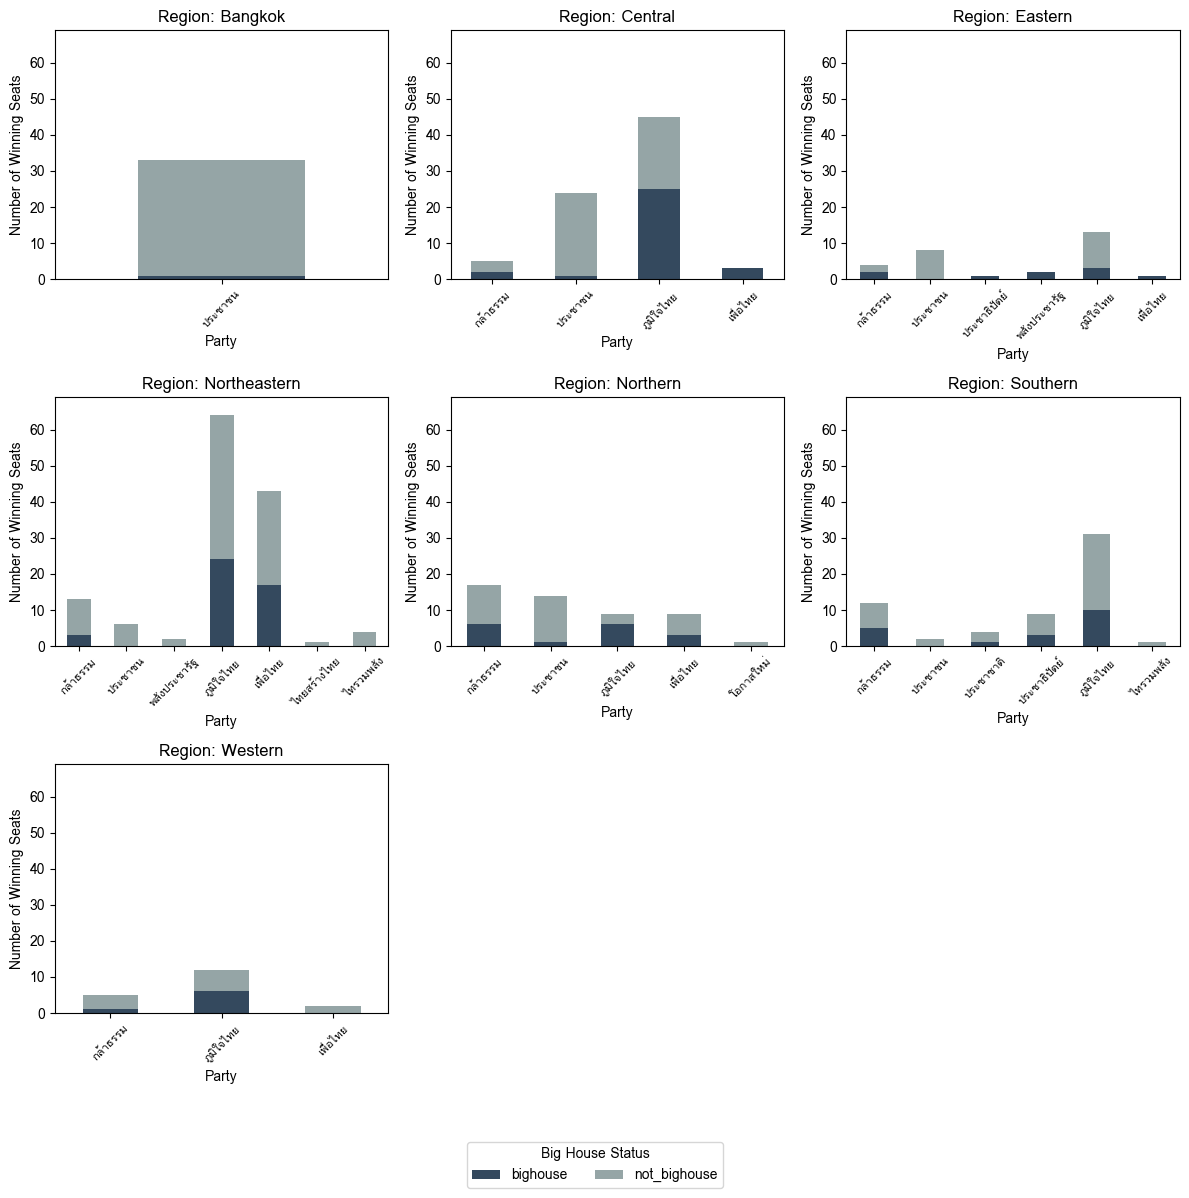

In [ ]:
num_regions = len(unique_regions)
num_cols = 3 # Number of columns in the subplot grid
num_rows = (num_regions + num_cols - 1) // num_cols # Calculate number of rows needed

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 4, num_rows * 4), squeeze=False)
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# Calculate the global maximum for 'winning_seats' to set a consistent y-axis scale
global_max_winning_seats = 0
for region_data in pivoted_data_by_region.values():
    global_max_winning_seats = max(global_max_winning_seats, region_data.sum(axis=1).max())

handles, labels = [], [] # To store handles and labels for a single legend

for i, region in enumerate(unique_regions):
    ax = axes[i]
    data = pivoted_data_by_region[region]

    # Plotting the stacked bar chart
    # Capture handles and labels from the first plot to create a single legend later
    if i == 0:
        plot_data = data.plot(kind='bar', ax=ax, stacked = True, color=['#34495e', '#95a5a6'])
        handles, labels = plot_data.get_legend_handles_labels()
    else:
        data.plot(kind='bar', ax=ax, stacked = True, color=['#34495e', '#95a5a6'])

    ax.set_title(f'Region: {region}', fontsize=12)
    ax.set_xlabel('Party', fontsize=10)
    ax.set_ylabel('Number of Winning Seats', fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=8) # Rotate x-axis labels and set labelsize
    ax.set_ylim(0, global_max_winning_seats + 5) # Set consistent y-axis limit, add a small buffer
    ax.get_legend().remove() # Remove individual legend from each subplot

# Turn off any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Create a single legend for the entire figure at the bottom
fig.legend(handles, labels, loc='lower center', title='Big House Status', ncol=len(labels), bbox_to_anchor=(0.5, 0.0),
           bbox_transform=fig.transFigure)


plt.tight_layout(rect=[0, 0.08, 1, 1]) # Adjust layout to make space for the legend at the bottom
plt.show()

In [ ]:
for region in unique_regions:
    print(f'------------------------------------------------------------\n\n{region}')
    data = pivoted_data_by_region[region]
    data['total_seats'] = data['bighouse'] + data['not_bighouse']
    # Avoid division by zero for parties with no seats
    data['bighouse_proportion'] = data.apply(lambda row: (row['bighouse'] / row['total_seats'])*100 if row['total_seats'] > 0 else 0, axis=1)
    display(data)

------------------------------------------------------------

Bangkok


bighouse,bighouse,not_bighouse,total_seats,bighouse_proportion
name,,,,
ประชาชน,1.0,32.0,33.0,3.030303


------------------------------------------------------------

Central


bighouse,bighouse,not_bighouse,total_seats,bighouse_proportion
name,,,,
กล้าธรรม,2.0,3.0,5.0,40.000000
ประชาชน,1.0,23.0,24.0,4.166667
ภูมิใจไทย,25.0,20.0,45.0,55.555556
เพื่อไทย,3.0,0.0,3.0,100.000000


------------------------------------------------------------

Eastern


...

bighouse,bighouse,not_bighouse,total_seats,bighouse_proportion
name,,,,
กล้าธรรม,6.0,11.0,17.0,35.294118
ประชาชน,1.0,13.0,14.0,7.142857
ภูมิใจไทย,6.0,3.0,9.0,66.666667
เพื่อไทย,3.0,6.0,9.0,33.333333
โอกาสใหม่,0.0,1.0,1.0,0.000000


------------------------------------------------------------

Southern


bighouse,bighouse,not_bighouse,total_seats,bighouse_proportion
name,,,,
กล้าธรรม,5.0,7.0,12.0,41.666667
ประชาชน,0.0,2.0,2.0,0.000000
ประชาชาติ,1.0,3.0,4.0,25.000000
ประชาธิปัตย์,3.0,6.0,9.0,33.333333
ภูมิใจไทย,10.0,21.0,31.0,32.258065
ไทรวมพลัง,0.0,1.0,1.0,0.000000


------------------------------------------------------------

Western


bighouse,bighouse,not_bighouse,total_seats,bighouse_proportion
name,,,,
กล้าธรรม,1.0,4.0,5.0,20.0
ภูมิใจไทย,6.0,6.0,12.0,50.0
เพื่อไทย,0.0,2.0,2.0,0.0


# กราฟวิเคราะห์อิทธิพล สส บ้านใหญ่ รายจังหวัด

In [ ]:
# Calculate X-axis: Average number of bighouse candidates per constituency in a province
# First, sum bighouse_no per constituency
constituency_bighouse_counts = df_cal_margin.groupby(['prov_id', 'cons_id'])['bighouse_no'].sum().reset_index()
constituency_bighouse_counts = constituency_bighouse_counts.rename(columns={'bighouse_no': 'num_bighouse_candidates_in_cons'})

# Then, average this count per province
avg_bighouse_per_cons_province = constituency_bighouse_counts.groupby('prov_id')['num_bighouse_candidates_in_cons'].mean().reset_index()
avg_bighouse_per_cons_province = avg_bighouse_per_cons_province.rename(columns={'num_bighouse_candidates_in_cons': 'avg_bighouse_candidates_per_cons'})

# Calculate Y-axis: Average proportion of bighouse votes to total votes in a constituency, averaged per province
# Sum vote percentages for bighouse candidates per constituency
bighouse_votes_per_cons = df_cal_margin[df_cal_margin['bighouse_no'] == 1].groupby(['prov_id', 'cons_id'])['mp_app_vote_percent'].sum().reset_index()
bighouse_votes_per_cons = bighouse_votes_per_cons.rename(columns={'mp_app_vote_percent': 'sum_bighouse_vote_percent_cons'})

# Sum total vote percentages for all candidates per constituency
total_votes_per_cons = df_cal_margin.groupby(['prov_id', 'cons_id'])['mp_app_vote_percent'].sum().reset_index()
total_votes_per_cons = total_votes_per_cons.rename(columns={'mp_app_vote_percent': 'sum_total_vote_percent_cons'})

# Merge and calculate proportion per constituency
constituency_vote_proportions = pd.merge(bighouse_votes_per_cons, total_votes_per_cons, on=['prov_id', 'cons_id'], how='outer').fillna(0)
constituency_vote_proportions['bighouse_vote_proportion_cons'] = (
    constituency_vote_proportions['sum_bighouse_vote_percent_cons'] / constituency_vote_proportions['sum_total_vote_percent_cons']
)
constituency_vote_proportions.replace([np.inf, -np.inf], np.nan, inplace=True) # Handle division by zero if total_votes_per_cons is 0
constituency_vote_proportions.fillna(0, inplace=True)

# Average this proportion per province
avg_bighouse_vote_proportion_province = constituency_vote_proportions.groupby('prov_id')['bighouse_vote_proportion_cons'].mean().reset_index()
avg_bighouse_vote_proportion_province = avg_bighouse_vote_proportion_province.rename(columns={'bighouse_vote_proportion_cons': 'avg_bighouse_vote_proportion_province'})

# Merge all calculated data with province and region information
df_province_metrics = pd.merge(avg_bighouse_per_cons_province, avg_bighouse_vote_proportion_province, on='prov_id')
df_province_metrics = pd.merge(df_province_metrics, df_province[['prov_id', 'province', 'region']], on='prov_id')

display(constituency_bighouse_counts)

,prov_id,cons_id,num_bighouse_candidates_in_cons
0,ACR,ACR_1,2
1,ACR,ACR_2,0
2,ATG,ATG_1,1
3,ATG,ATG_2,1
4,AYA,AYA_1,0
...,...,...,...
395,YLA,YLA_2,1
396,YLA,YLA_3,0
397,YST,YST_1,2
398,YST,YST_2,2


In [ ]:
median_candidates = df_province_metrics['avg_bighouse_candidates_per_cons'].median()
median_vote_proportion = df_province_metrics['avg_bighouse_vote_proportion_province'].median()

print(f"Median Average Bighouse Candidates per Constituency: {median_candidates:.2f}")
print(f"Median Average Bighouse Vote Proportion per Province: {median_vote_proportion:.2f}")

Median Average Bighouse Candidates per Constituency: 0.57
Median Average Bighouse Vote Proportion per Province: 0.22


In [ ]:
low_bighouse_influence_provinces = df_province_metrics[
    (df_province_metrics['avg_bighouse_candidates_per_cons'] < median_candidates) &
    (df_province_metrics['avg_bighouse_vote_proportion_province'] < median_vote_proportion)
].sort_values(by=['avg_bighouse_candidates_per_cons', 'avg_bighouse_vote_proportion_province']).reset_index(drop=True)

display(low_bighouse_influence_provinces)

,prov_id,avg_bighouse_candidates_per_cons,avg_bighouse_vote_proportion_province,province,region
0,BKN,0.000000,0.000000,บึงกาฬ,Northeastern
1,CTI,0.000000,0.000000,จันทบุรี,Eastern
2,NBI,0.000000,0.000000,นนทบุรี,Central
3,PNA,0.000000,0.000000,พังงา,Southern
4,SBR,0.000000,0.000000,สิงห์บุรี,Central
5,CMI,0.100000,0.047543,เชียงใหม่,Northern
6,AYA,0.200000,0.113465,พระนครศรีอยุธยา,Central
7,TRG,0.250000,0.085043,ตรัง,Southern
8,SRN,0.250000,0.090971,สุรินทร์,Northeastern
9,SRI,0.250000,0.096364,สระบุรี,Central


In [ ]:
df_province_metrics['is_low_influence'] = False
df_province_metrics.loc[df_province_metrics['province'].isin(low_bighouse_influence_provinces['province']), 'is_low_influence'] = True

display(df_province_metrics.head())

,prov_id,avg_bighouse_candidates_per_cons,avg_bighouse_vote_proportion_province,province,region,is_low_influence
0,ACR,1.000000,0.373669,อำนาจเจริญ,Northeastern,False
1,ATG,1.000000,0.730180,อ่างทอง,Central,False
2,AYA,0.200000,0.113465,พระนครศรีอยุธยา,Central,True
3,BKK,0.393939,0.072701,กรุงเทพมหานคร,Bangkok,True
4,BKN,0.000000,0.000000,บึงกาฬ,Northeastern,True


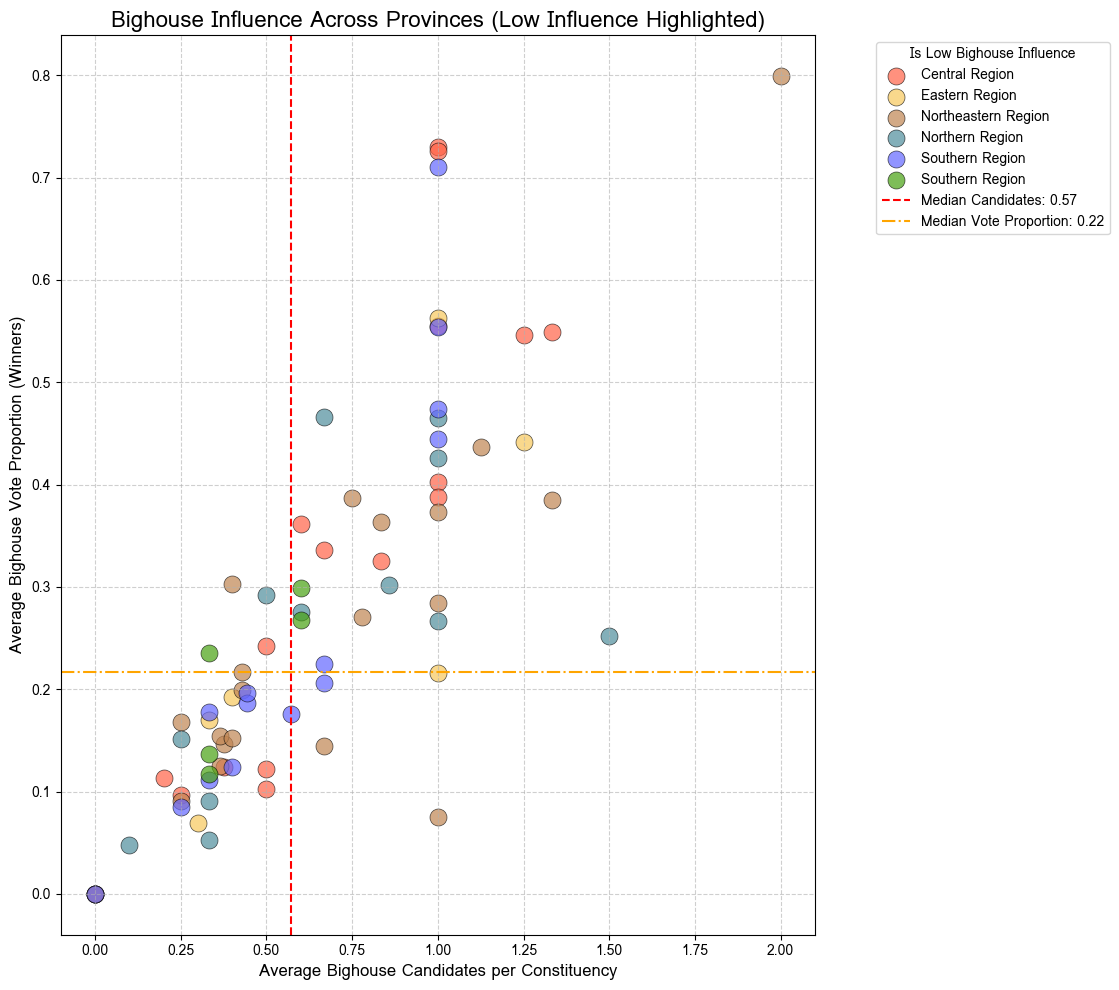

In [ ]:
df_province_metrics['is_central_region'] = df_province_metrics['region'] == 'Central'
df_province_metrics['is_eastern_region'] = df_province_metrics['region'] == 'Eastern'
df_province_metrics['is_Northeastern_region'] = df_province_metrics['region'] == 'Northeastern'
df_province_metrics['is_Northern_region'] = df_province_metrics['region'] == 'Northern'
df_province_metrics['is_Southern_region'] = df_province_metrics['region'] == 'Southern'
df_province_metrics['is_Western_region'] = df_province_metrics['region'] == 'Western'

plt.figure(figsize=(12, 10))

central_points = sns.scatterplot(
    x='avg_bighouse_candidates_per_cons',
    y='avg_bighouse_vote_proportion_province',
    data=df_province_metrics[df_province_metrics['is_central_region'] == True],
    color='#FF6347',
    s=150,
    edgecolor='black',
    alpha=0.7,
    label='Central Region',
    linewidth = 0.5,
    ax=plt.gca()
)

eastern_points = sns.scatterplot(
    x='avg_bighouse_candidates_per_cons',
    y='avg_bighouse_vote_proportion_province',
    data=df_province_metrics[df_province_metrics['is_eastern_region'] == True],
    color='#F7C85C',
    s=150,
    edgecolor='black',
    alpha=0.7,
    label='Eastern Region',
    linewidth = 0.5,
    ax=plt.gca()
)

Northeastern_points = sns.scatterplot(
    x='avg_bighouse_candidates_per_cons',
    y='avg_bighouse_vote_proportion_province',
    data=df_province_metrics[df_province_metrics['is_Northeastern_region'] == True],
    color='#C08552',
    s=150,
    edgecolor='black',
    alpha=0.7,
    label='Northeastern Region',
    linewidth = 0.5,
    ax=plt.gca()
)

Northern_points = sns.scatterplot(
    x='avg_bighouse_candidates_per_cons',
    y='avg_bighouse_vote_proportion_province',
    data=df_province_metrics[df_province_metrics['is_Northern_region'] == True],
    color='#4E8D9C',
    s=150,
    edgecolor='black',
    alpha=0.7,
    label='Northern Region',
    linewidth = 0.5,
    ax=plt.gca()
)

southern_points = sns.scatterplot(
    x='avg_bighouse_candidates_per_cons',
    y='avg_bighouse_vote_proportion_province',
    data=df_province_metrics[df_province_metrics['is_Southern_region'] == True],
    color='#6367FF',
    s=150,
    edgecolor='black',
    alpha=0.7,
    label='Southern Region',
    linewidth = 0.5,
    ax=plt.gca()
)

western_points = sns.scatterplot(
    x='avg_bighouse_candidates_per_cons',
    y='avg_bighouse_vote_proportion_province',
    data=df_province_metrics[df_province_metrics['is_Western_region'] == True],
    color='#48A111',
    s=150,
    edgecolor='black',
    alpha=0.7,
    label='Southern Region',
    linewidth = 0.5,
    ax=plt.gca()
)


# Add median thresholds
plt.axvline(median_candidates, color='red', linestyle='--', label=f'Median Candidates: {median_candidates:.2f}')
plt.axhline(median_vote_proportion, color='orange', linestyle='-.', label=f'Median Vote Proportion: {median_vote_proportion:.2f}')

plt.title('Bighouse Influence Across Provinces (Low Influence Highlighted)', fontsize=16)
plt.xlabel('Average Bighouse Candidates per Constituency', fontsize=12)
plt.ylabel('Average Bighouse Vote Proportion (Winners)', fontsize=12)
plt.legend(title='Is Low Bighouse Influence', loc='upper right', bbox_to_anchor=(1.4, 1))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

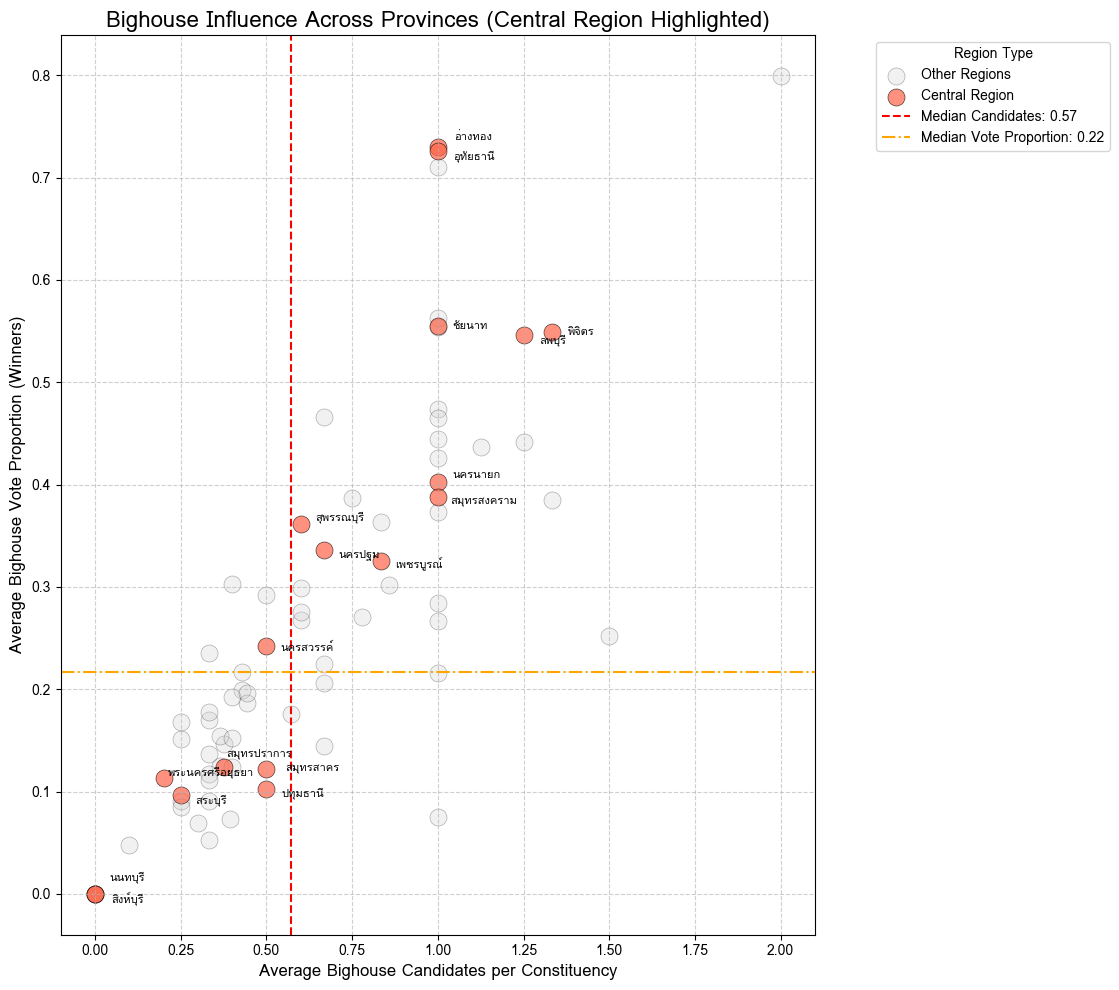

In [ ]:
df_province_metrics['is_central_region'] = df_province_metrics['region'] == 'Central'

plt.figure(figsize=(12, 10))

# Plot non-Central regions first with lower alpha and capture its artist objects
non_central_points = sns.scatterplot(
    x='avg_bighouse_candidates_per_cons',
    y='avg_bighouse_vote_proportion_province',
    data=df_province_metrics[df_province_metrics['is_central_region'] == False],
    color='#D3D3D3',
    s=150,
    edgecolor='black',
    alpha=0.3,
    label='Other Regions',
    linewidth = 0.5,
    ax=plt.gca()
)

# Plot Central region on top with higher alpha and capture its artist objects
central_points = sns.scatterplot(
    x='avg_bighouse_candidates_per_cons',
    y='avg_bighouse_vote_proportion_province',
    data=df_province_metrics[df_province_metrics['is_central_region'] == True],
    color='#FF6347',
    s=150,
    edgecolor='black',
    alpha=0.7,
    label='Central Region',
    linewidth = 0.5,
    ax=plt.gca()
)

# Add median thresholds (keep as gray)
plt.axvline(median_candidates, color='red', linestyle='--', label=f'Median Candidates: {median_candidates:.2f}')
plt.axhline(median_vote_proportion, color='orange', linestyle='-.', label=f'Median Vote Proportion: {median_vote_proportion:.2f}')

texts = []
# Create text labels for Central region provinces
for i, row in df_province_metrics.iterrows():
    if row['is_central_region']:
        texts.append(plt.text(
            row['avg_bighouse_candidates_per_cons'] + 0.05,
            row['avg_bighouse_vote_proportion_province'],
            row['province'],
            fontsize=8,
            color='black',
            ha='left',
            va= 'center'
        ))

all_scatter_objects = central_points.collections
adjust_text(texts, add_objects=all_scatter_objects, expand_points=(5, 5), force_point=(15, 15))

plt.title('Bighouse Influence Across Provinces (Central Region Highlighted)', fontsize=16)
plt.xlabel('Average Bighouse Candidates per Constituency', fontsize=12)
plt.ylabel('Average Bighouse Vote Proportion (Winners)', fontsize=12)
plt.legend(title='Region Type', loc='upper right', bbox_to_anchor=(1.4, 1))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

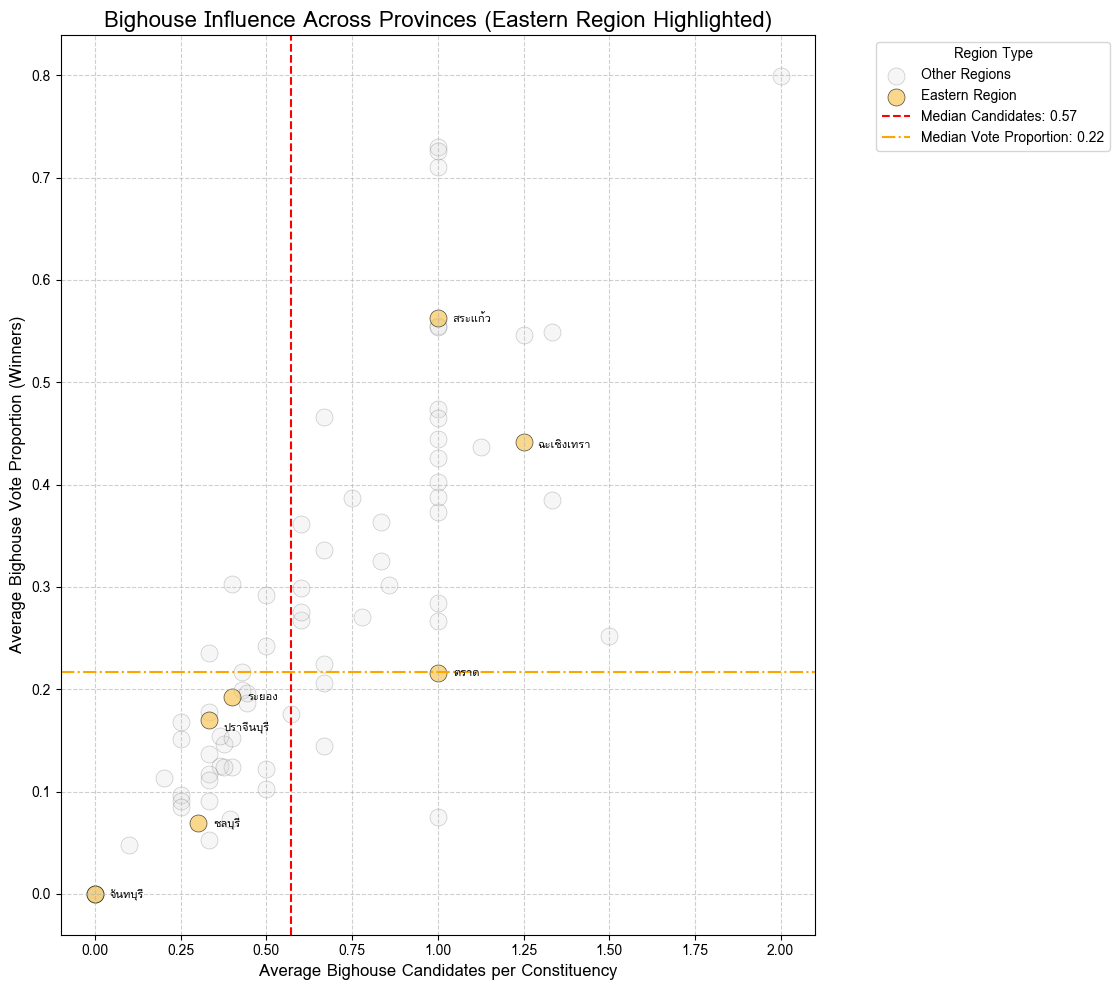

In [ ]:
df_province_metrics['is_eastern_region'] = df_province_metrics['region'] == 'Eastern'

plt.figure(figsize=(12, 10))

# Plot non-Central regions first with lower alpha and capture its artist objects
non_eastern_points = sns.scatterplot(
    x='avg_bighouse_candidates_per_cons',
    y='avg_bighouse_vote_proportion_province',
    data=df_province_metrics[df_province_metrics['is_eastern_region'] == False],
    color='#D3D3D3',
    s=150,
    edgecolor='black',
    alpha=0.2,
    label='Other Regions',
    linewidth = 0.5,
    ax=plt.gca()
)

# Plot Central region on top with higher alpha and capture its artist objects
eastern_points = sns.scatterplot(
    x='avg_bighouse_candidates_per_cons',
    y='avg_bighouse_vote_proportion_province',
    data=df_province_metrics[df_province_metrics['is_eastern_region'] == True],
    color='#F7C85C',
    s=150,
    edgecolor='black',
    alpha=0.7,
    label='Eastern Region',
    linewidth = 0.5,
    ax=plt.gca()
)

# Add median thresholds (keep as gray)
plt.axvline(median_candidates, color='red', linestyle='--', label=f'Median Candidates: {median_candidates:.2f}')
plt.axhline(median_vote_proportion, color='orange', linestyle='-.', label=f'Median Vote Proportion: {median_vote_proportion:.2f}')

texts = []
# Create text labels for Central region provinces
for i, row in df_province_metrics.iterrows():
    if row['is_eastern_region']:
        texts.append(plt.text(
            row['avg_bighouse_candidates_per_cons'] + 0.05,
            row['avg_bighouse_vote_proportion_province'],
            row['province'],
            fontsize=8,
            color='black',
            ha='left',
            va= 'center'
        ))

all_scatter_objects = eastern_points.collections
adjust_text(texts, add_objects=all_scatter_objects, expand_points=(5, 5), force_point=(15, 15))

plt.title('Bighouse Influence Across Provinces (Eastern Region Highlighted)', fontsize=16)
plt.xlabel('Average Bighouse Candidates per Constituency', fontsize=12)
plt.ylabel('Average Bighouse Vote Proportion (Winners)', fontsize=12)
plt.legend(title='Region Type', loc='upper right', bbox_to_anchor=(1.4, 1))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

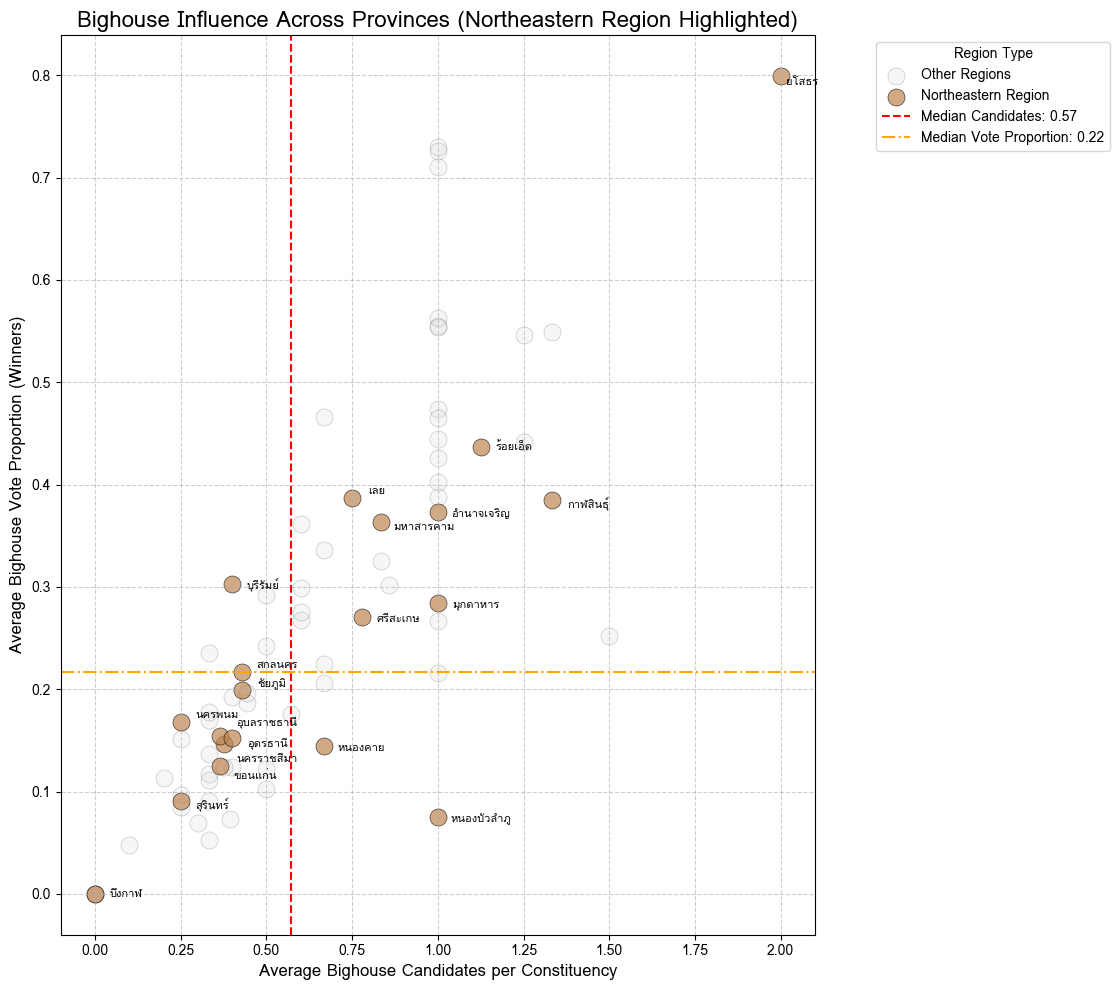

In [ ]:
df_province_metrics['is_Northeastern_region'] = df_province_metrics['region'] == 'Northeastern'

plt.figure(figsize=(12, 10))

# Plot non-Central regions first with lower alpha and capture its artist objects
non_Northeastern_points = sns.scatterplot(
    x='avg_bighouse_candidates_per_cons',
    y='avg_bighouse_vote_proportion_province',
    data=df_province_metrics[df_province_metrics['is_Northeastern_region'] == False],
    color='#D3D3D3',
    s=150,
    edgecolor='black',
    alpha=0.2,
    label='Other Regions',
    linewidth = 0.5,
    ax=plt.gca()
)

# Plot Central region on top with higher alpha and capture its artist objects
Northeastern_points = sns.scatterplot(
    x='avg_bighouse_candidates_per_cons',
    y='avg_bighouse_vote_proportion_province',
    data=df_province_metrics[df_province_metrics['is_Northeastern_region'] == True],
    color='#C08552',
    s=150,
    edgecolor='black',
    alpha=0.7,
    label='Northeastern Region',
    linewidth = 0.5,
    ax=plt.gca()
)

# Add median thresholds (keep as gray)
plt.axvline(median_candidates, color='red', linestyle='--', label=f'Median Candidates: {median_candidates:.2f}')
plt.axhline(median_vote_proportion, color='orange', linestyle='-.', label=f'Median Vote Proportion: {median_vote_proportion:.2f}')

texts = []
# Create text labels for Central region provinces
for i, row in df_province_metrics.iterrows():
    if row['is_Northeastern_region']:
        texts.append(plt.text(
            row['avg_bighouse_candidates_per_cons'] + 0.05,
            row['avg_bighouse_vote_proportion_province'],
            row['province'],
            fontsize=8,
            color='black',
            ha='left',
            va= 'center'
        ))

all_scatter_objects = eastern_points.collections
adjust_text(texts, add_objects=all_scatter_objects, expand_points=(5, 5), force_point=(15, 15))

plt.title('Bighouse Influence Across Provinces (Northeastern Region Highlighted)', fontsize=16)
plt.xlabel('Average Bighouse Candidates per Constituency', fontsize=12)
plt.ylabel('Average Bighouse Vote Proportion (Winners)', fontsize=12)
plt.legend(title='Region Type', loc='upper right', bbox_to_anchor=(1.4, 1))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

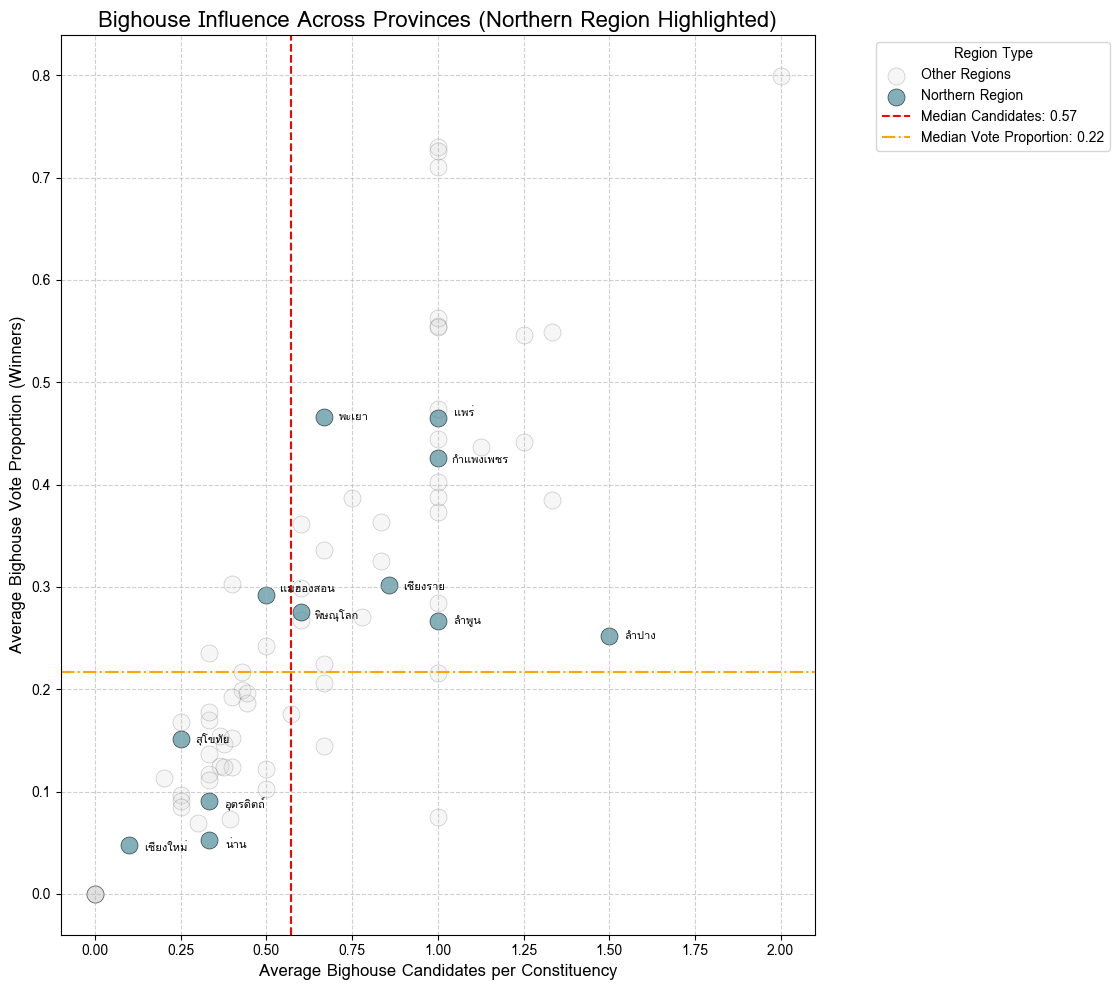

In [ ]:
df_province_metrics['is_Northern_region'] = df_province_metrics['region'] == 'Northern'

plt.figure(figsize=(12, 10))

# Plot non-Central regions first with lower alpha and capture its artist objects
non_Northern_points = sns.scatterplot(
    x='avg_bighouse_candidates_per_cons',
    y='avg_bighouse_vote_proportion_province',
    data=df_province_metrics[df_province_metrics['is_Northern_region'] == False],
    color='#D3D3D3',
    s=150,
    edgecolor='black',
    alpha=0.2,
    label='Other Regions',
    linewidth = 0.5,
    ax=plt.gca()
)

# Plot Central region on top with higher alpha and capture its artist objects
Northern_points = sns.scatterplot(
    x='avg_bighouse_candidates_per_cons',
    y='avg_bighouse_vote_proportion_province',
    data=df_province_metrics[df_province_metrics['is_Northern_region'] == True],
    color='#4E8D9C',
    s=150,
    edgecolor='black',
    alpha=0.7,
    label='Northern Region',
    linewidth = 0.5,
    ax=plt.gca()
)

# Add median thresholds (keep as gray)
plt.axvline(median_candidates, color='red', linestyle='--', label=f'Median Candidates: {median_candidates:.2f}')
plt.axhline(median_vote_proportion, color='orange', linestyle='-.', label=f'Median Vote Proportion: {median_vote_proportion:.2f}')

texts = []
# Create text labels for Central region provinces
for i, row in df_province_metrics.iterrows():
    if row['is_Northern_region']:
        texts.append(plt.text(
            row['avg_bighouse_candidates_per_cons'] + 0.05,
            row['avg_bighouse_vote_proportion_province'],
            row['province'],
            fontsize=8,
            color='black',
            ha='left',
            va= 'center'
        ))

all_scatter_objects = eastern_points.collections
adjust_text(texts, add_objects=all_scatter_objects, expand_points=(5, 5), force_point=(15, 15))

plt.title('Bighouse Influence Across Provinces (Northern Region Highlighted)', fontsize=16)
plt.xlabel('Average Bighouse Candidates per Constituency', fontsize=12)
plt.ylabel('Average Bighouse Vote Proportion (Winners)', fontsize=12)
plt.legend(title='Region Type', loc='upper right', bbox_to_anchor=(1.4, 1))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

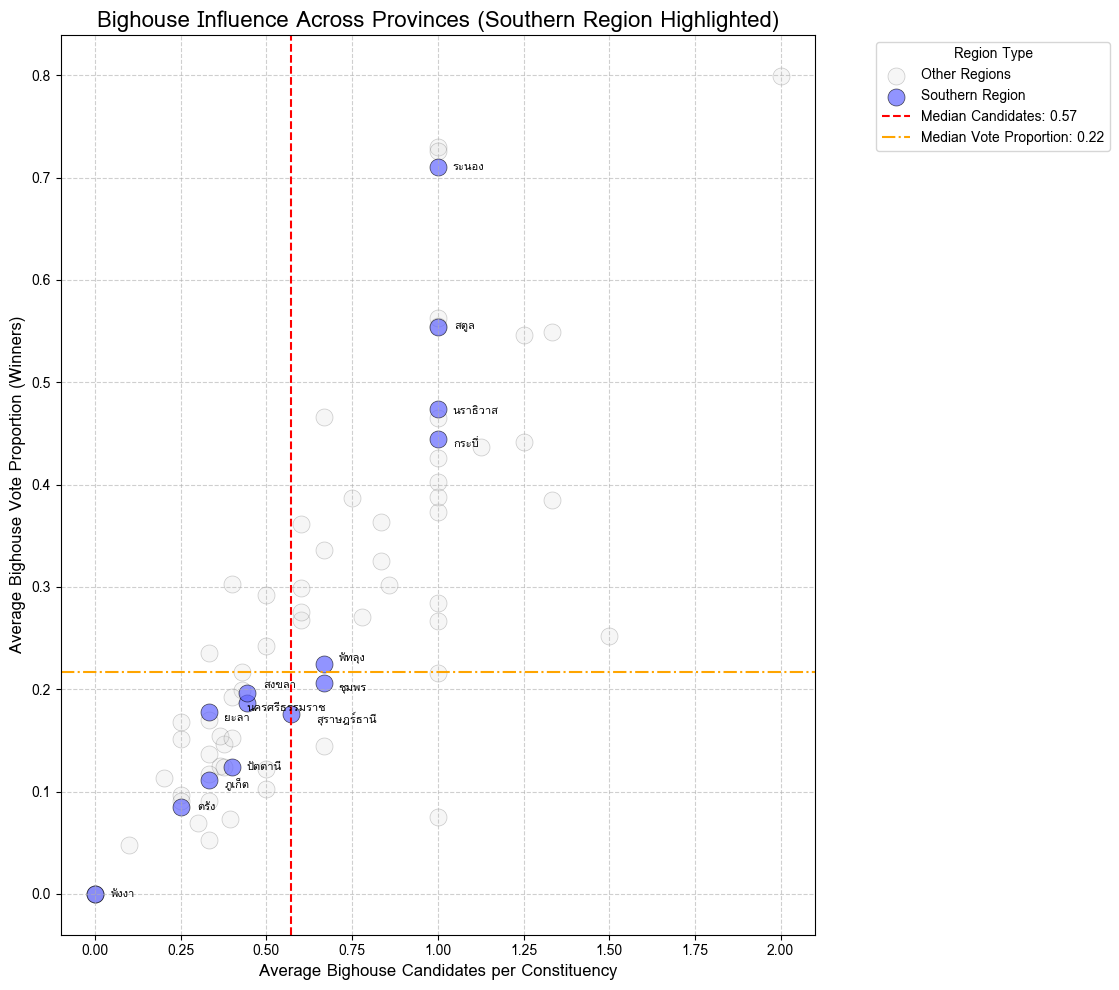

In [ ]:
df_province_metrics['is_Southern_region'] = df_province_metrics['region'] == 'Southern'

plt.figure(figsize=(12, 10))

# Plot non-Central regions first with lower alpha and capture its artist objects
non_southern_points = sns.scatterplot(
    x='avg_bighouse_candidates_per_cons',
    y='avg_bighouse_vote_proportion_province',
    data=df_province_metrics[df_province_metrics['is_Southern_region'] == False],
    color='#D3D3D3',
    s=150,
    edgecolor='black',
    alpha=0.2,
    label='Other Regions',
    linewidth = 0.5,
    ax=plt.gca()
)

# Plot Central region on top with higher alpha and capture its artist objects
southern_points = sns.scatterplot(
    x='avg_bighouse_candidates_per_cons',
    y='avg_bighouse_vote_proportion_province',
    data=df_province_metrics[df_province_metrics['is_Southern_region'] == True],
    color='#6367FF',
    s=150,
    edgecolor='black',
    alpha=0.7,
    label='Southern Region',
    linewidth = 0.5,
    ax=plt.gca()
)

# Add median thresholds (keep as gray)
plt.axvline(median_candidates, color='red', linestyle='--', label=f'Median Candidates: {median_candidates:.2f}')
plt.axhline(median_vote_proportion, color='orange', linestyle='-.', label=f'Median Vote Proportion: {median_vote_proportion:.2f}')

texts = []
# Create text labels for Central region provinces
for i, row in df_province_metrics.iterrows():
    if row['is_Southern_region']:
        texts.append(plt.text(
            row['avg_bighouse_candidates_per_cons'] + 0.05,
            row['avg_bighouse_vote_proportion_province'],
            row['province'],
            fontsize=8,
            color='black',
            ha='left',
            va= 'center'
        ))

all_scatter_objects = southern_points.collections
adjust_text(texts, add_objects=all_scatter_objects, expand_points=(5, 5), force_point=(15, 15))

plt.title('Bighouse Influence Across Provinces (Southern Region Highlighted)', fontsize=16)
plt.xlabel('Average Bighouse Candidates per Constituency', fontsize=12)
plt.ylabel('Average Bighouse Vote Proportion (Winners)', fontsize=12)
plt.legend(title='Region Type', loc='upper right', bbox_to_anchor=(1.4, 1))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

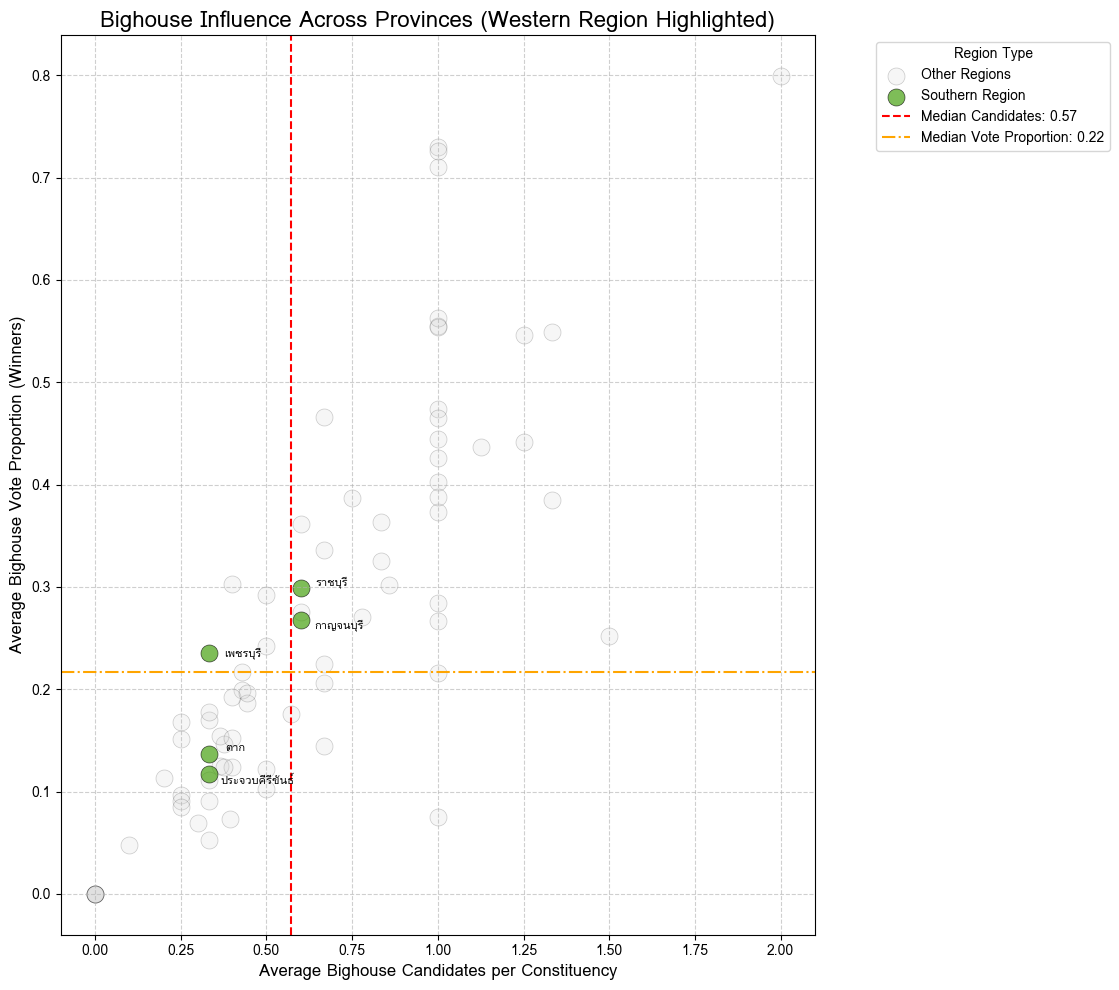

In [ ]:
df_province_metrics['is_Western_region'] = df_province_metrics['region'] == 'Western'

plt.figure(figsize=(12, 10))

# Plot non-Central regions first with lower alpha and capture its artist objects
non_western_points = sns.scatterplot(
    x='avg_bighouse_candidates_per_cons',
    y='avg_bighouse_vote_proportion_province',
    data=df_province_metrics[df_province_metrics['is_Western_region'] == False],
    color='#D3D3D3',
    s=150,
    edgecolor='black',
    alpha=0.2,
    label='Other Regions',
    linewidth = 0.5,
    ax=plt.gca()
)

# Plot Central region on top with higher alpha and capture its artist objects
western_points = sns.scatterplot(
    x='avg_bighouse_candidates_per_cons',
    y='avg_bighouse_vote_proportion_province',
    data=df_province_metrics[df_province_metrics['is_Western_region'] == True],
    color='#48A111',
    s=150,
    edgecolor='black',
    alpha=0.7,
    label='Southern Region',
    linewidth = 0.5,
    ax=plt.gca()
)

# Add median thresholds (keep as gray)
plt.axvline(median_candidates, color='red', linestyle='--', label=f'Median Candidates: {median_candidates:.2f}')
plt.axhline(median_vote_proportion, color='orange', linestyle='-.', label=f'Median Vote Proportion: {median_vote_proportion:.2f}')

texts = []
# Create text labels for Central region provinces
for i, row in df_province_metrics.iterrows():
    if row['is_Western_region']:
        texts.append(plt.text(
            row['avg_bighouse_candidates_per_cons'] + 0.05,
            row['avg_bighouse_vote_proportion_province'],
            row['province'],
            fontsize=8,
            color='black',
            ha='left',
            va= 'center'
        ))

all_scatter_objects = western_points.collections
adjust_text(texts, add_objects=all_scatter_objects, expand_points=(5, 5), force_point=(15, 15))

plt.title('Bighouse Influence Across Provinces (Western Region Highlighted)', fontsize=16)
plt.xlabel('Average Bighouse Candidates per Constituency', fontsize=12)
plt.ylabel('Average Bighouse Vote Proportion (Winners)', fontsize=12)
plt.legend(title='Region Type', loc='upper right', bbox_to_anchor=(1.4, 1))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()